**Kepler Object of Interest (KOI) Classification**

This notebook develops a supervised classification pipeline to determine the disposition of a Kepler Object of Interest — CANDIDATE, CONFIRMED, or FALSE POSITIVE — using photometric and stellar parameters recorded by the Kepler mission. Each observation corresponds to a transit signal detected by the telescope, along with the physical and orbital characteristics inferred from that signal.

The objective is to build a model capable of distinguishing genuine exoplanet candidates from false positives using only the raw observational and derived features, without relying on the dataset's own precomputed disposition scores, in order to avoid target leakage.

The workflow proceeds as follows: exploratory analysis and missing-value assessment, statistically justified feature selection (ANOVA and chi-squared testing), outlier handling and imputation, feature engineering from measurement uncertainty columns, and finally, training and comparison of five classification algorithms via cross-validated hyperparameter search.

In [55]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import set_config
set_config(transform_output="pandas")

In [56]:
df = pd.read_csv("../data/dataset.csv")

In [57]:
df.sample(10)


,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
7788,7789,5282656,K06551.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.193,0,0,1,...,-236.0,4.456,0.056,-0.224,1.046,0.341,-0.114,293.98837,40.458981,15.160
3057,3058,11521048,K00540.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,1,...,-149.0,4.488,0.108,-0.132,0.835,0.169,-0.099,297.76697,49.446659,14.917
972,973,11497958,K01422.02,Kepler-296 d,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-78.0,4.866,0.066,-0.044,0.383,0.048,-0.058,286.54001,49.437328,15.921
2975,2976,10189546,K00427.01,NaN,CANDIDATE,CANDIDATE,1.000,0,0,0,...,-79.0,4.384,0.137,-0.074,0.986,0.107,-0.117,283.02280,47.261131,14.621
2230,2231,6183511,K02542.01,NaN,CANDIDATE,CANDIDATE,0.958,0,0,0,...,-83.0,4.920,0.058,-0.071,0.356,0.057,-0.057,283.40195,41.516331,15.527
4888,4889,3544694,K03629.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-227.0,4.246,0.153,-0.187,1.303,0.395,-0.263,291.44626,38.639778,15.925
8360,8361,5966732,K06641.01,NaN,CANDIDATE,CANDIDATE,0.965,0,0,0,...,-244.0,4.474,0.065,-0.195,0.975,0.289,-0.096,293.79370,41.204491,15.514
2208,2209,10861715,K02537.01,NaN,FALSE POSITIVE,FALSE POSITIVE,NaN,0,0,0,...,-175.0,4.553,0.031,-0.260,0.848,0.299,-0.067,292.02341,48.226959,15.309
6503,6504,7970194,K05453.01,NaN,FALSE POSITIVE,FALSE POSITIVE,NaN,1,0,0,...,-141.0,4.549,0.032,-0.266,0.835,0.335,-0.066,295.27673,43.706509,15.043
5186,5187,10795103,K03683.01,Kepler-1515 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-141.0,4.287,0.063,-0.117,1.357,0.242,-0.138,290.97394,48.178162,12.040


In [58]:
df.shape


(9564, 50)

The dataset contains 50 columns; the first step is to identify which features are relevant to the classification task.

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9564 entries, 0 to 9563
Data columns (total 50 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rowid              9564 non-null   int64  
 1   kepid              9564 non-null   int64  
 2   kepoi_name         9564 non-null   object 
 3   kepler_name        2294 non-null   object 
 4   koi_disposition    9564 non-null   object 
 5   koi_pdisposition   9564 non-null   object 
 6   koi_score          8054 non-null   float64
 7   koi_fpflag_nt      9564 non-null   int64  
 8   koi_fpflag_ss      9564 non-null   int64  
 9   koi_fpflag_co      9564 non-null   int64  
 10  koi_fpflag_ec      9564 non-null   int64  
 11  koi_period         9564 non-null   float64
 12  koi_period_err1    9110 non-null   float64
 13  koi_period_err2    9110 non-null   float64
 14  koi_time0bk        9564 non-null   float64
 15  koi_time0bk_err1   9110 non-null   float64
 16  koi_time0bk_err2   9110 

In [60]:
df.describe()

,rowid,kepid,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,koi_period,koi_period_err1,koi_period_err2,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
count,9564.000000,9.564000e+03,8054.000000,9564.000000,9564.000000,9564.000000,9564.000000,9564.000000,9110.000000,9110.000000,...,9081.000000,9201.000000,9096.000000,9096.000000,9201.000000,9096.000000,9096.000000,9564.000000,9564.000000,9563.000000
mean,4782.500000,7.690628e+06,0.480829,0.188206,0.231598,0.194898,0.120033,75.671358,0.002148,-0.002148,...,-162.265059,4.310157,0.120738,-0.143161,1.728712,0.362292,-0.394806,292.060163,43.810433,14.264606
std,2761.033321,2.653459e+06,0.476928,0.390897,0.421875,0.396143,0.325018,1334.744046,0.008236,0.008236,...,72.746348,0.432606,0.132837,0.085477,6.127185,0.930870,2.168213,4.766657,3.601243,1.385448
min,1.000000,7.574500e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.241843,0.000000,-0.172500,...,-1762.000000,0.047000,0.000000,-1.207000,0.109000,0.000000,-116.137000,279.852720,36.577381,6.966000
25%,2391.750000,5.556034e+06,0.000000,0.000000,0.000000,0.000000,0.000000,2.733684,0.000005,-0.000276,...,-198.000000,4.218000,0.042000,-0.196000,0.829000,0.129000,-0.250000,288.660770,40.777173,13.440000
50%,4782.500000,7.906892e+06,0.334000,0.000000,0.000000,0.000000,0.000000,9.752831,0.000035,-0.000035,...,-160.000000,4.438000,0.070000,-0.128000,1.000000,0.251000,-0.111000,292.261125,43.677504,14.520000
75%,7173.250000,9.873066e+06,0.998000,0.000000,0.000000,0.000000,0.000000,40.715178,0.000276,-0.000005,...,-114.000000,4.543000,0.149000,-0.088000,1.345000,0.364000,-0.069000,295.859160,46.714611,15.322000
max,9564.000000,1.293514e+07,1.000000,1.000000,1.000000,1.000000,1.000000,129995.778400,0.172500,0.000000,...,0.000000,5.364000,1.472000,0.000000,229.908000,33.091000,0.000000,301.720760,52.336010,20.003000


Columns at index 30 and 31 contain entirely missing values and will therefore be dropped in a later step.

This is a multi-class classification problem, and the subsequent analysis is framed accordingly.

In [61]:

df.drop(df.columns[[0,1,30,31]], axis=1, inplace=True)

In [62]:
df.shape

(9564, 46)

In [63]:
(df.isnull().sum()*100)/len(df)

kepoi_name            0.000000
kepler_name          76.014220
koi_disposition       0.000000
koi_pdisposition      0.000000
koi_score            15.788373
koi_fpflag_nt         0.000000
koi_fpflag_ss         0.000000
koi_fpflag_co         0.000000
koi_fpflag_ec         0.000000
koi_period            0.000000
koi_period_err1       4.746968
koi_period_err2       4.746968
koi_time0bk           0.000000
koi_time0bk_err1      4.746968
koi_time0bk_err2      4.746968
koi_impact            3.795483
koi_impact_err1       4.746968
koi_impact_err2       4.746968
koi_duration          0.000000
koi_duration_err1     4.746968
koi_duration_err2     4.746968
koi_depth             3.795483
koi_depth_err1        4.746968
koi_depth_err2        4.746968
koi_prad              3.795483
koi_prad_err1         3.795483
koi_prad_err2         3.795483
koi_teq               3.795483
koi_insol             3.356336
koi_insol_err1        3.356336
koi_insol_err2        3.356336
koi_model_snr         3.795483
koi_tce_

In [64]:
df.duplicated().sum()

np.int64(0)

No duplicate rows are present; however, the dataset contains a lot of missing data that will require imputation.

Given the number of columns and the extent of missing data, the relevant features must first be identified. This will be done statistically, using a t-test for binary categories and ANOVA for categories with more than two levels. Columns with no plausible predictive value, such as kepler_name and the row index, will also be dropped.

Several object-type (string) columns are candidates for removal, since identifiers and names are typically arbitrary and unlikely to carry predictive signal unless they encode a genuine category. Chi-squared and ANOVA tests will be used to confirm this before any column is dropped.

Missing values will be imputed using a ColumnTransformer; since set_config(transform_output="pandas") is enabled, the transformer output will be returned as a DataFrame.

In [65]:
df.drop(["kepler_name", "koi_pdisposition","koi_score"],axis=1, inplace=True)

kepler_name was dropped due to approximately 76% missing values. koi_score and koi_pdisposition were dropped because they represent predictions from the dataset's original disposition model; retaining them as input features would leak information about the target into the model.

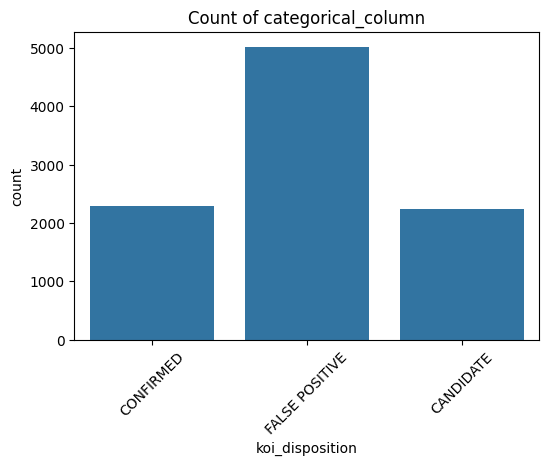

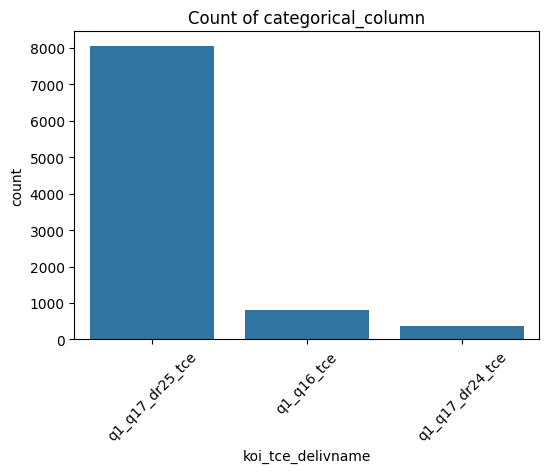

In [66]:
categorical=['koi_disposition','koi_tce_delivname']
for cat in categorical:
    plt.figure(figsize=(6,4))
    sns.countplot(x=cat, data=df)
    plt.title('Count of categorical_column')
    plt.xticks(rotation=45)
    plt.show()

In [67]:
pd.unique(df['kepoi_name'])

array(['K00752.01', 'K00752.02', 'K00753.01', ..., 'K07986.01',
       'K07987.01', 'K07989.01'], shape=(9564,), dtype=object)

All values in kepoi_name are unique identifiers, so the column offers no predictive value, and one-hot encoding it would substantially and unnecessarily inflate the feature space.

kepoi_name will therefore be excluded from further analysis.

In [68]:
((df['koi_tce_delivname'].value_counts())*100)/len(df)

koi_tce_delivname
q1_q17_dr25_tce    84.211627
q1_q16_tce          8.322877
q1_q17_dr24_tce     3.847762
Name: count, dtype: float64

Random sample imputation will be used for the categorical column to preserve its original distribution, rather than a KNN-based approach, which would require retaining the training distribution in memory to serve at inference time.

In [69]:
df.drop(['kepoi_name'],axis=1, inplace=True)

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9564 entries, 0 to 9563
Data columns (total 42 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   koi_disposition    9564 non-null   object 
 1   koi_fpflag_nt      9564 non-null   int64  
 2   koi_fpflag_ss      9564 non-null   int64  
 3   koi_fpflag_co      9564 non-null   int64  
 4   koi_fpflag_ec      9564 non-null   int64  
 5   koi_period         9564 non-null   float64
 6   koi_period_err1    9110 non-null   float64
 7   koi_period_err2    9110 non-null   float64
 8   koi_time0bk        9564 non-null   float64
 9   koi_time0bk_err1   9110 non-null   float64
 10  koi_time0bk_err2   9110 non-null   float64
 11  koi_impact         9201 non-null   float64
 12  koi_impact_err1    9110 non-null   float64
 13  koi_impact_err2    9110 non-null   float64
 14  koi_duration       9564 non-null   float64
 15  koi_duration_err1  9110 non-null   float64
 16  koi_duration_err2  9110 

In [71]:
df_num=df.drop(['koi_tce_delivname'],axis=1)

In [72]:
df_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9564 entries, 0 to 9563
Data columns (total 41 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   koi_disposition    9564 non-null   object 
 1   koi_fpflag_nt      9564 non-null   int64  
 2   koi_fpflag_ss      9564 non-null   int64  
 3   koi_fpflag_co      9564 non-null   int64  
 4   koi_fpflag_ec      9564 non-null   int64  
 5   koi_period         9564 non-null   float64
 6   koi_period_err1    9110 non-null   float64
 7   koi_period_err2    9110 non-null   float64
 8   koi_time0bk        9564 non-null   float64
 9   koi_time0bk_err1   9110 non-null   float64
 10  koi_time0bk_err2   9110 non-null   float64
 11  koi_impact         9201 non-null   float64
 12  koi_impact_err1    9110 non-null   float64
 13  koi_impact_err2    9110 non-null   float64
 14  koi_duration       9564 non-null   float64
 15  koi_duration_err1  9110 non-null   float64
 16  koi_duration_err2  9110 

In [73]:
df_num_col=df_num.columns
print(df_num_col)

Index(['koi_disposition', 'koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co',
       'koi_fpflag_ec', 'koi_period', 'koi_period_err1', 'koi_period_err2',
       'koi_time0bk', 'koi_time0bk_err1', 'koi_time0bk_err2', 'koi_impact',
       'koi_impact_err1', 'koi_impact_err2', 'koi_duration',
       'koi_duration_err1', 'koi_duration_err2', 'koi_depth', 'koi_depth_err1',
       'koi_depth_err2', 'koi_prad', 'koi_prad_err1', 'koi_prad_err2',
       'koi_teq', 'koi_insol', 'koi_insol_err1', 'koi_insol_err2',
       'koi_model_snr', 'koi_tce_plnt_num', 'koi_steff', 'koi_steff_err1',
       'koi_steff_err2', 'koi_slogg', 'koi_slogg_err1', 'koi_slogg_err2',
       'koi_srad', 'koi_srad_err1', 'koi_srad_err2', 'ra', 'dec',
       'koi_kepmag'],
      dtype='object')


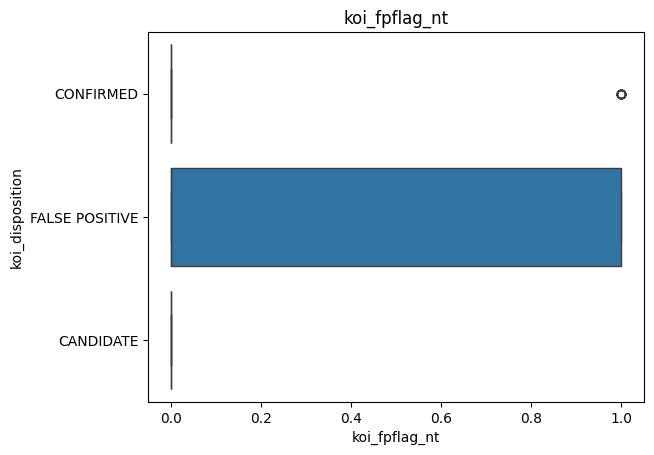

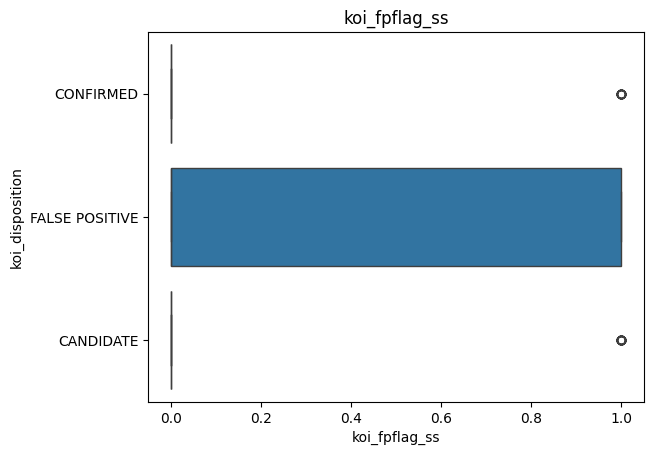

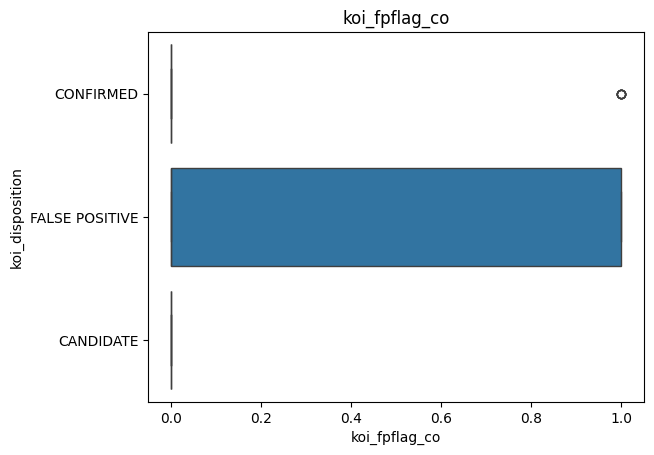

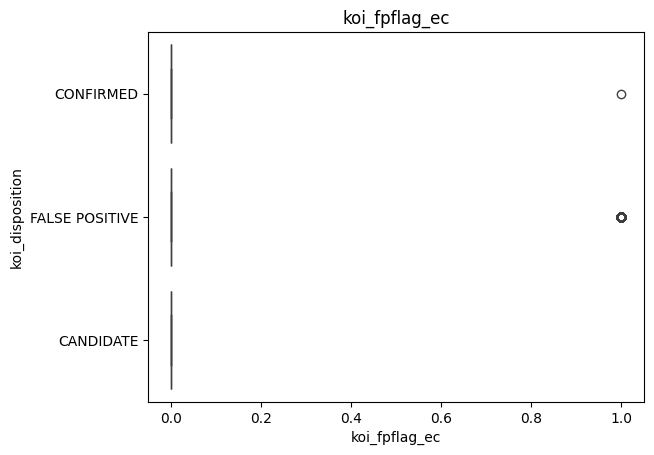

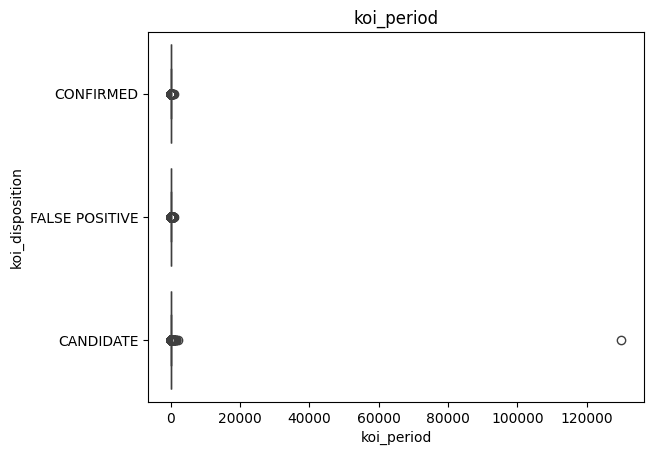

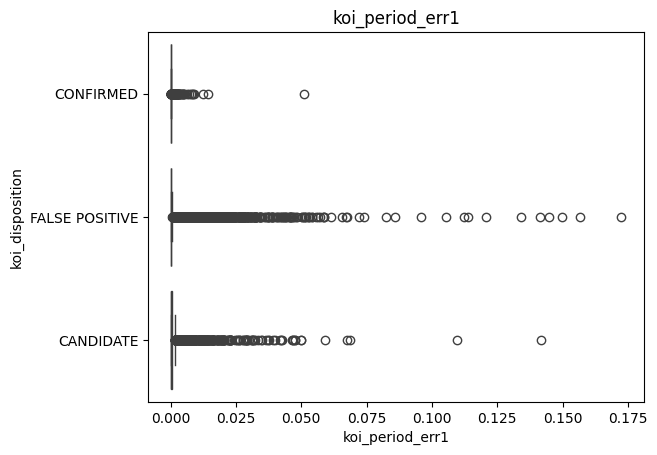

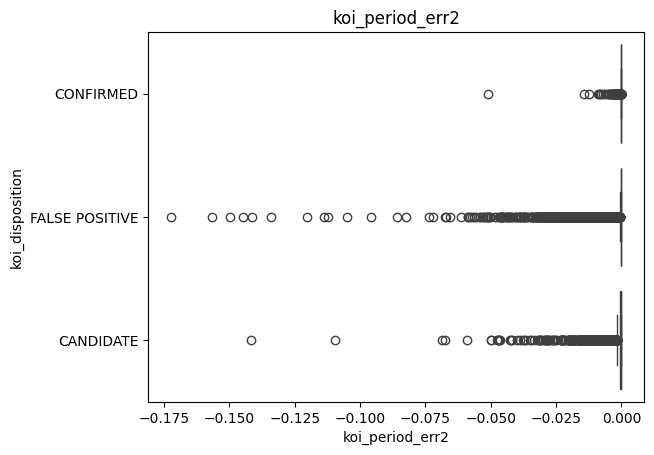

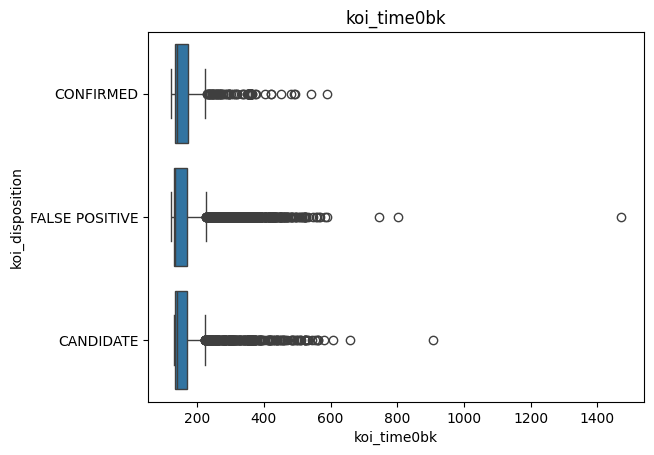

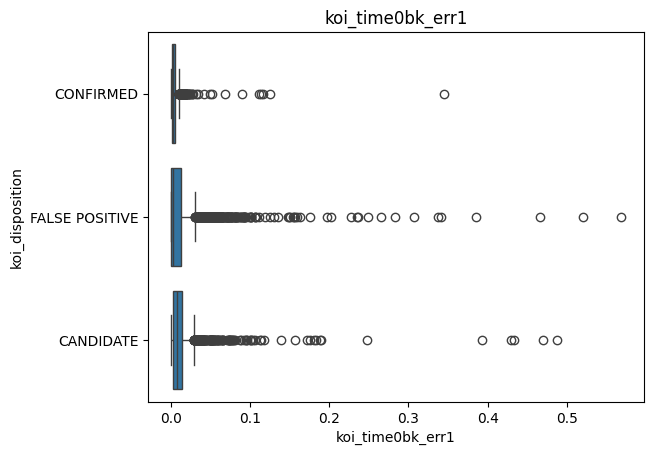

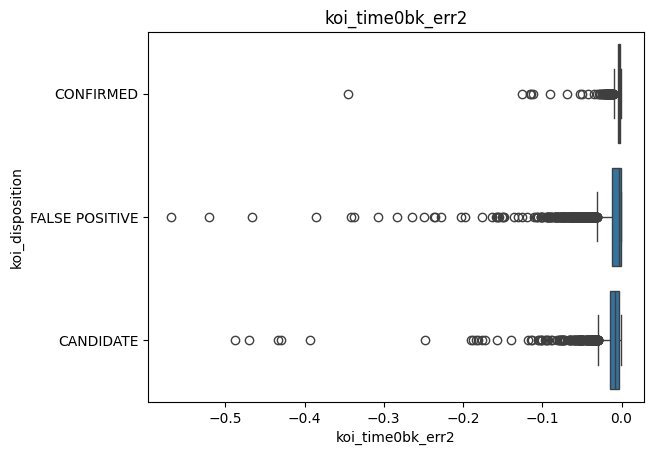

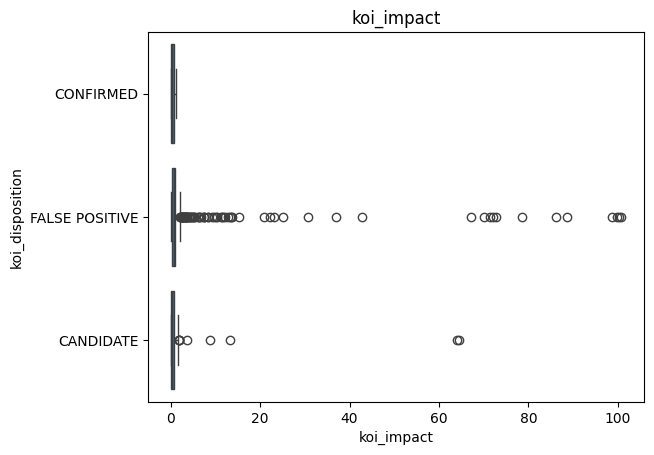

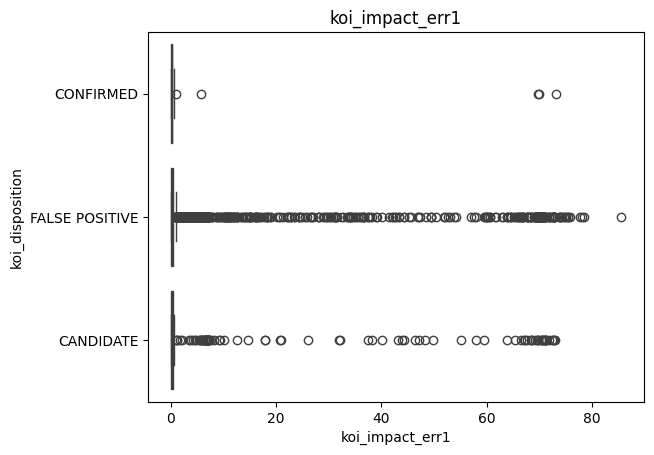

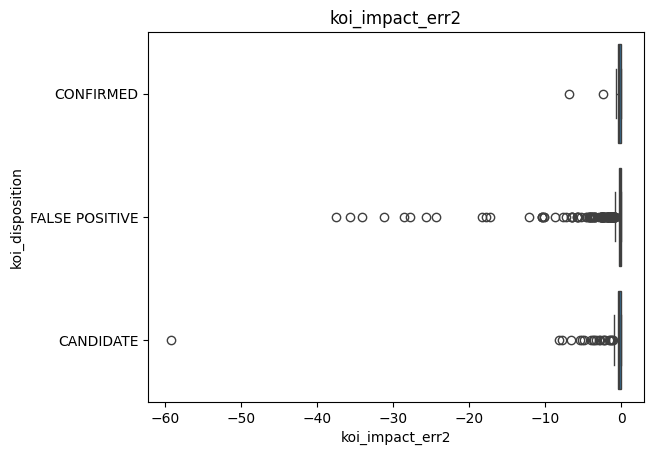

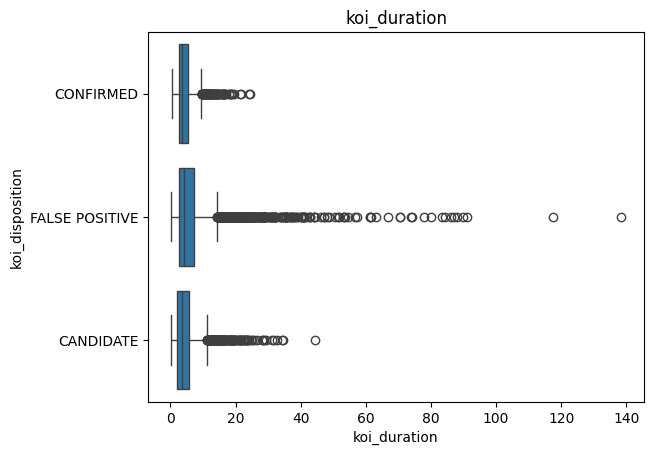

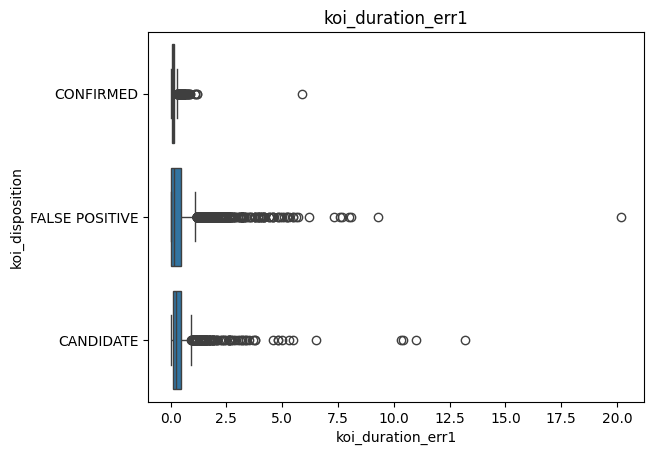

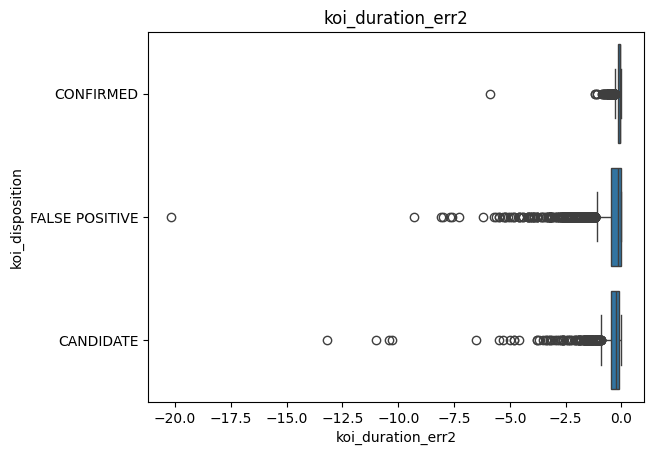

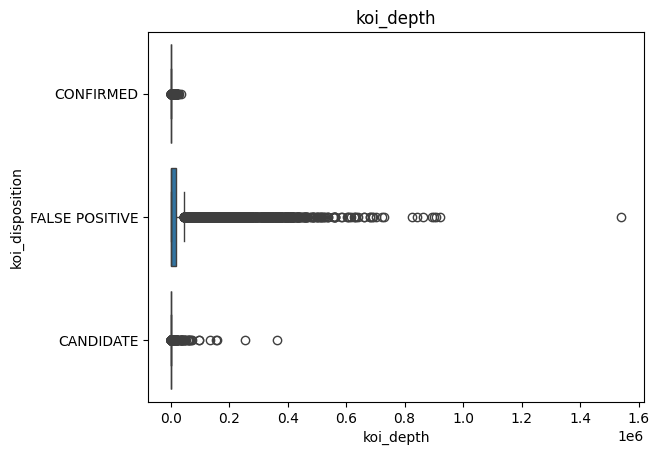

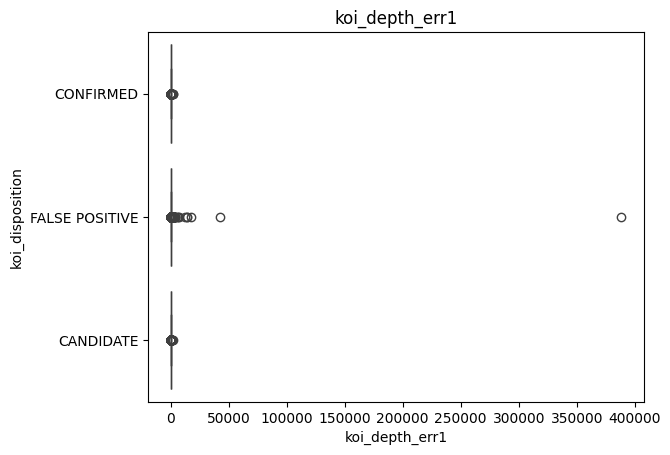

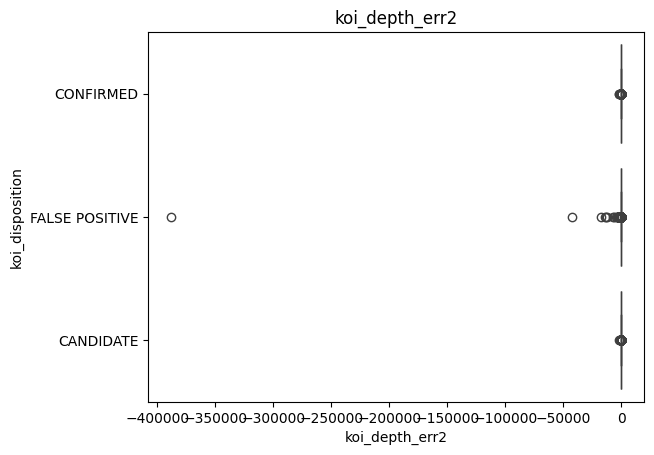

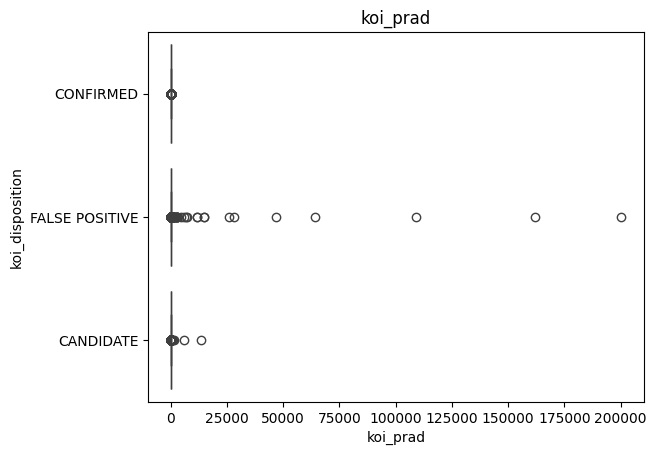

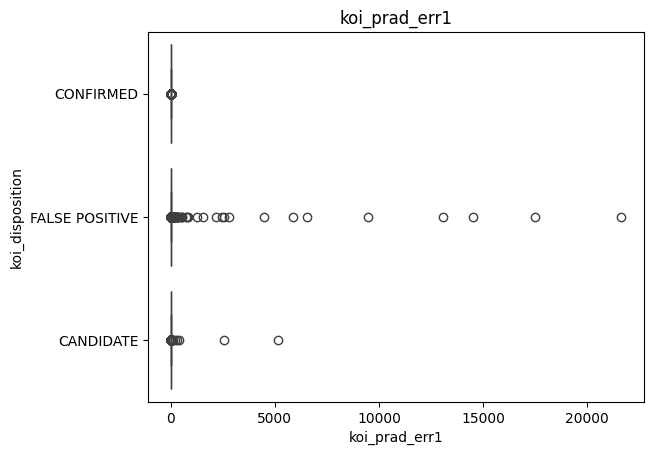

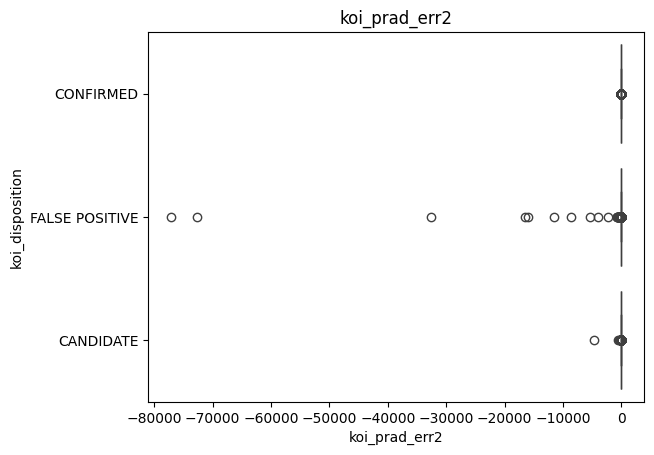

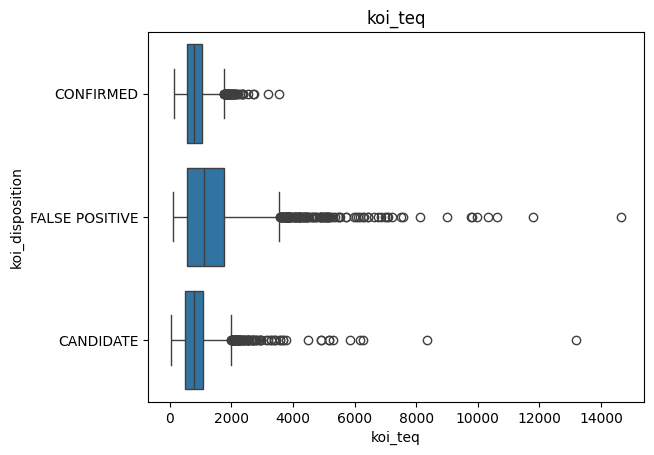

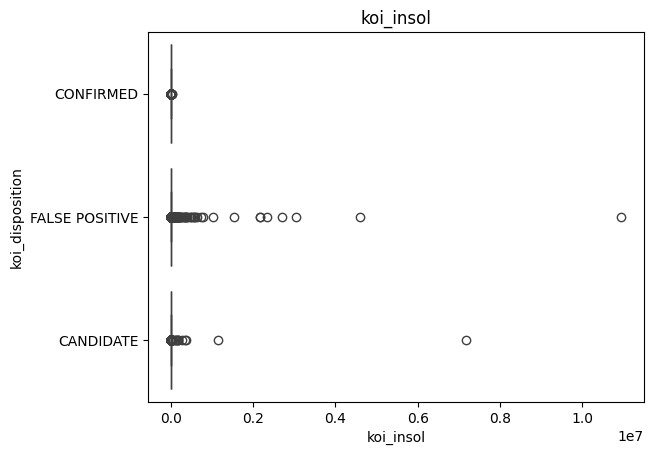

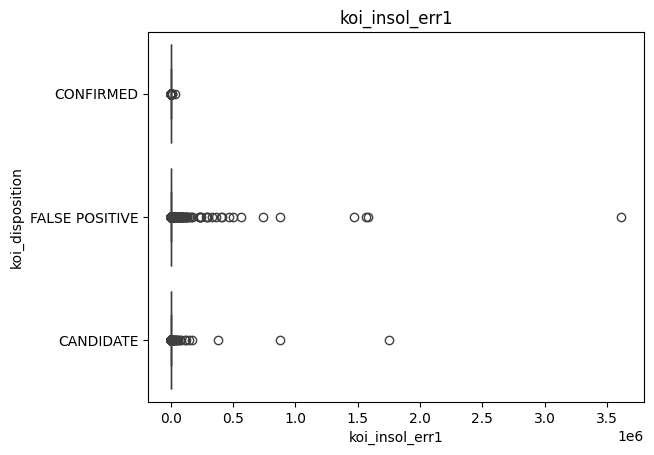

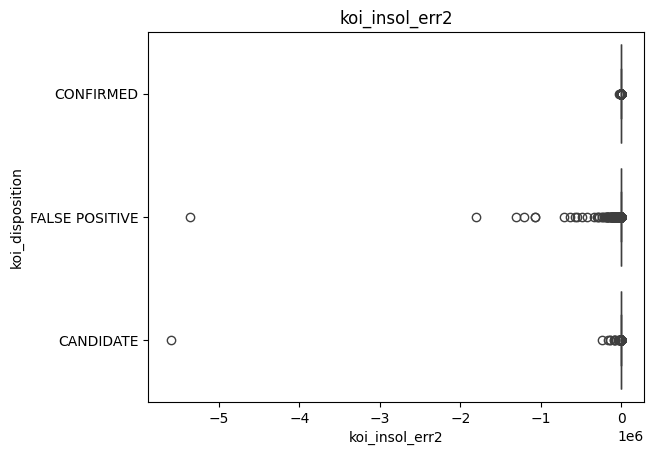

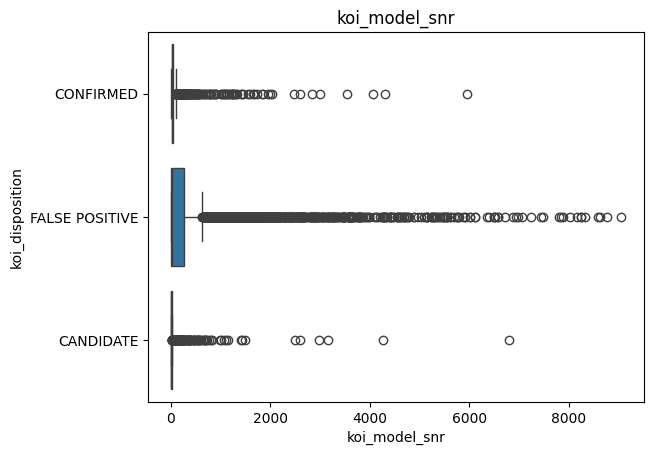

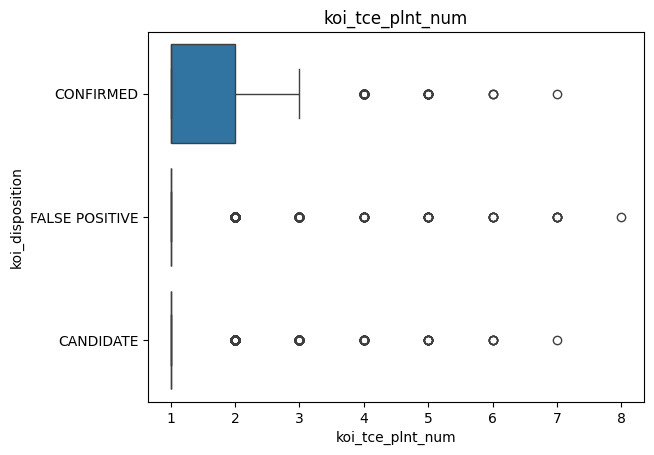

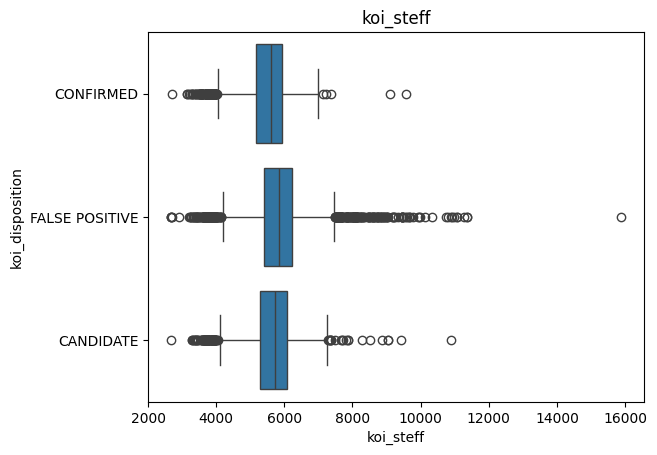

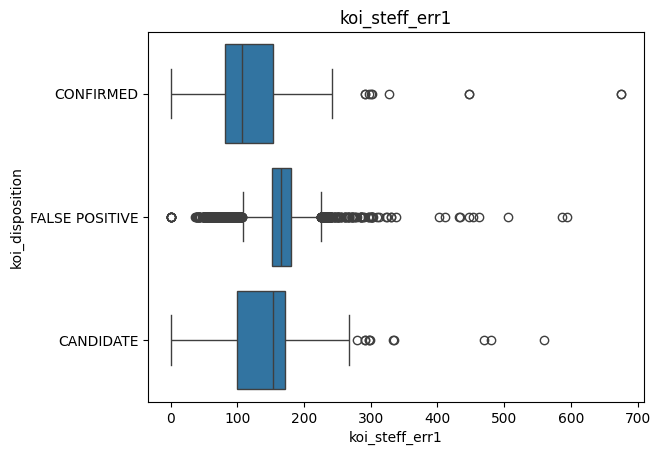

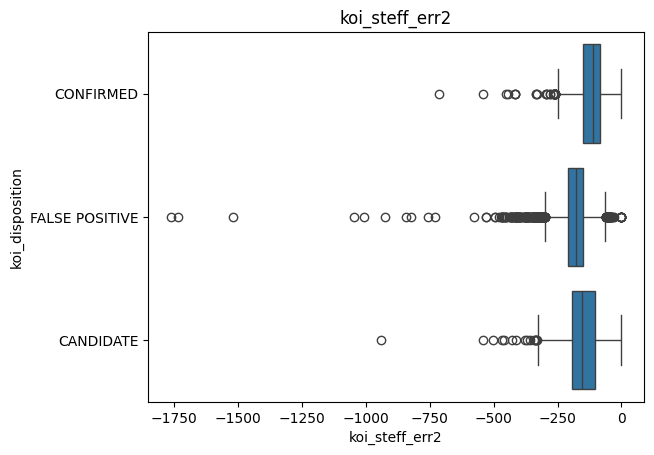

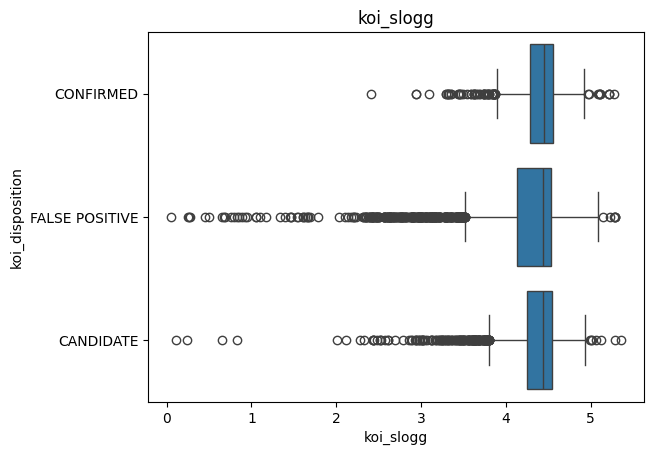

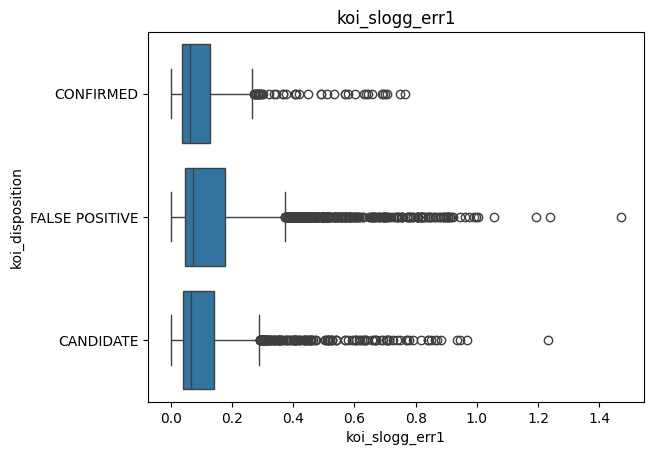

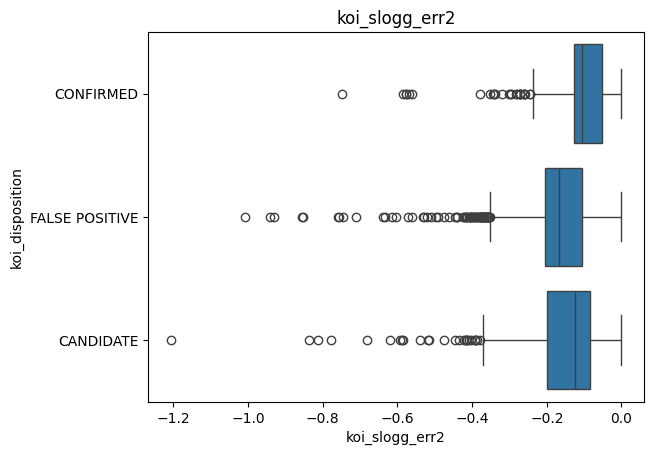

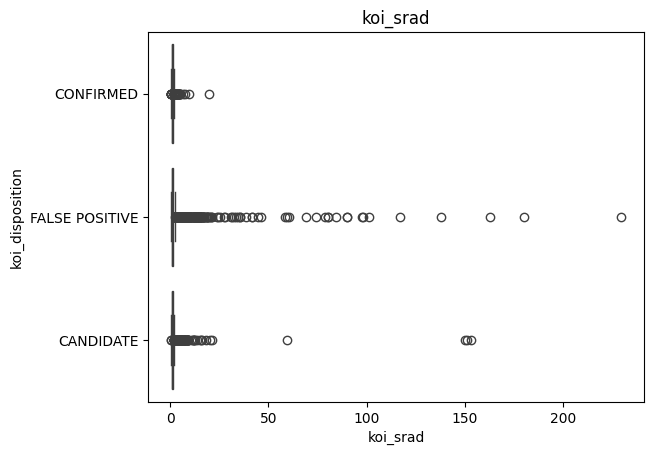

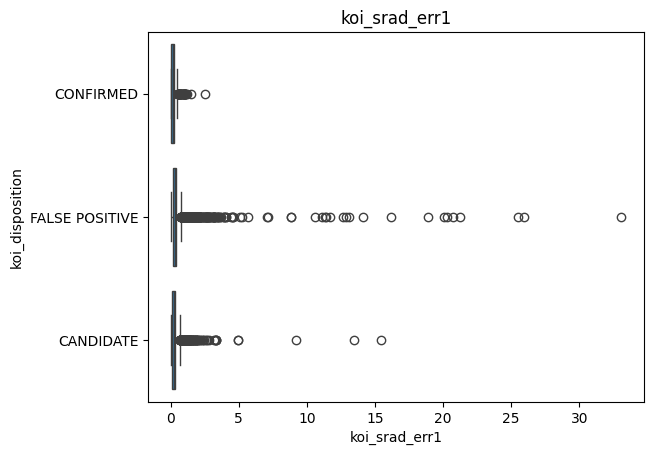

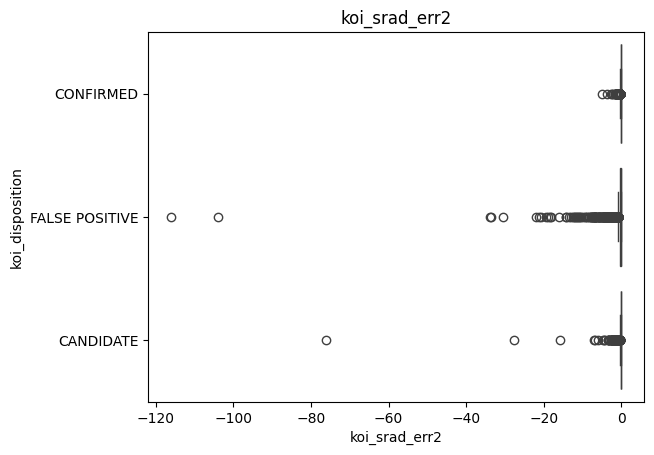

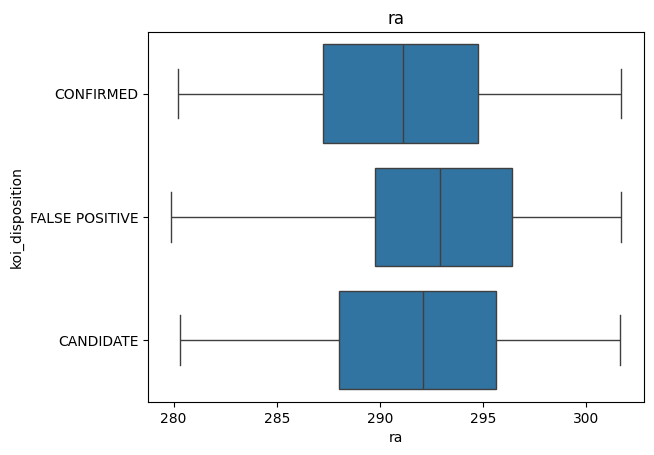

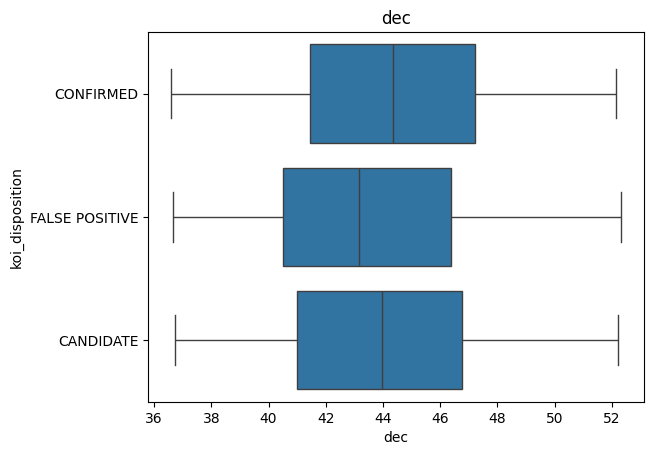

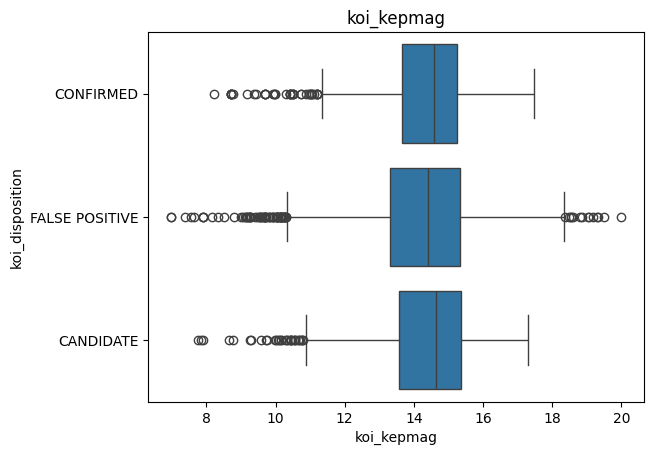

In [74]:
for i in df_num_col:
    if i!='koi_disposition':
        sns.boxplot(x=i,y='koi_disposition',data=df_num)
        plt.title(i)
        plt.show()

In [75]:
df_num.drop(['koi_disposition'],axis=1).skew()

koi_fpflag_nt         1.595610
koi_fpflag_ss         1.272691
koi_fpflag_co         1.540689
koi_fpflag_ec         2.338618
koi_period           96.459326
koi_period_err1       8.516557
koi_period_err2      -8.516557
koi_time0bk           3.682070
koi_time0bk_err1     11.166367
koi_time0bk_err2    -11.166367
koi_impact           23.505943
koi_impact_err1       6.341046
koi_impact_err2     -26.531371
koi_duration          5.928765
koi_duration_err1     8.295464
koi_duration_err2    -8.295464
koi_depth             5.260652
koi_depth_err1       92.693639
koi_depth_err2      -92.693639
koi_prad             52.118954
koi_prad_err1        40.588184
koi_prad_err2       -56.766792
koi_teq               3.505694
koi_insol            49.947777
koi_insol_err1       42.902621
koi_insol_err2      -53.738018
koi_model_snr         5.307083
koi_tce_plnt_num      3.665103
koi_steff             0.749782
koi_steff_err1        0.763875
koi_steff_err2       -4.517709
koi_slogg            -3.433093
koi_slog

Numerical missing values will be imputed using a KNN imputer. The train/test split is performed first, before any imputation is applied.

In [76]:
from sklearn.model_selection import train_test_split

In [77]:
X_train, X_test, y_train,y_test=train_test_split(df.drop(["koi_disposition"], axis=1),df["koi_disposition"],
                                                 random_state=42, test_size=0.2)

The train/test split is performed prior to imputation to prevent information from the test set from leaking into the training process.

A pipeline will be constructed to sequence the preprocessing steps, with the output used for subsequent statistical analysis; additional pipelines may be added later for encoding as needed.

Values will first be scaled and then passed through a KNN imputer, since KNN imputation is a multivariate, distance-based method well suited to this type of missing data.

In [78]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer

In [79]:
from sklearn.compose import ColumnTransformer

In [80]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7651 entries, 8117 to 7270
Data columns (total 41 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   koi_fpflag_nt      7651 non-null   int64  
 1   koi_fpflag_ss      7651 non-null   int64  
 2   koi_fpflag_co      7651 non-null   int64  
 3   koi_fpflag_ec      7651 non-null   int64  
 4   koi_period         7651 non-null   float64
 5   koi_period_err1    7283 non-null   float64
 6   koi_period_err2    7283 non-null   float64
 7   koi_time0bk        7651 non-null   float64
 8   koi_time0bk_err1   7283 non-null   float64
 9   koi_time0bk_err2   7283 non-null   float64
 10  koi_impact         7358 non-null   float64
 11  koi_impact_err1    7283 non-null   float64
 12  koi_impact_err2    7283 non-null   float64
 13  koi_duration       7651 non-null   float64
 14  koi_duration_err1  7283 non-null   float64
 15  koi_duration_err2  7283 non-null   float64
 16  koi_depth          7358 no

Outlier detection is performed before KNN imputation and scaling, since KNN imputation relies on distance calculations that outliers can distort.

Outlier detection will be performed on a per-column basis to avoid introducing inconsistencies in later analysis.

In [81]:
numeric_columns=X_train.columns.drop('koi_tce_delivname')
print(numeric_columns)

Index(['koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec',
       'koi_period', 'koi_period_err1', 'koi_period_err2', 'koi_time0bk',
       'koi_time0bk_err1', 'koi_time0bk_err2', 'koi_impact', 'koi_impact_err1',
       'koi_impact_err2', 'koi_duration', 'koi_duration_err1',
       'koi_duration_err2', 'koi_depth', 'koi_depth_err1', 'koi_depth_err2',
       'koi_prad', 'koi_prad_err1', 'koi_prad_err2', 'koi_teq', 'koi_insol',
       'koi_insol_err1', 'koi_insol_err2', 'koi_model_snr', 'koi_tce_plnt_num',
       'koi_steff', 'koi_steff_err1', 'koi_steff_err2', 'koi_slogg',
       'koi_slogg_err1', 'koi_slogg_err2', 'koi_srad', 'koi_srad_err1',
       'koi_srad_err2', 'ra', 'dec', 'koi_kepmag'],
      dtype='object')


c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:453: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=figsize)


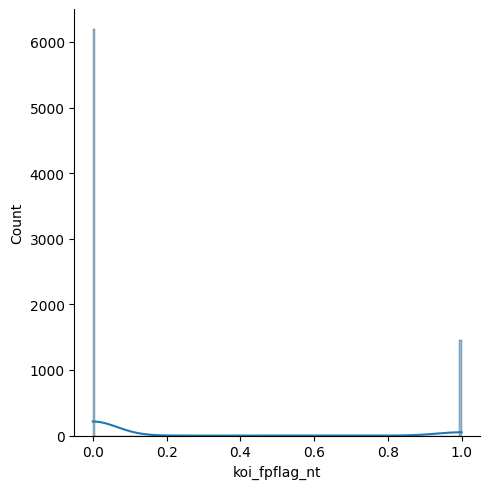

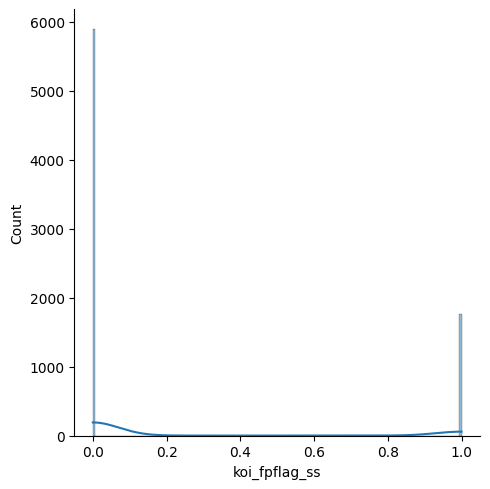

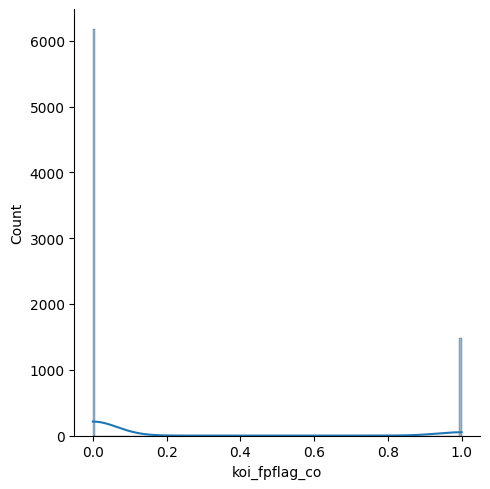

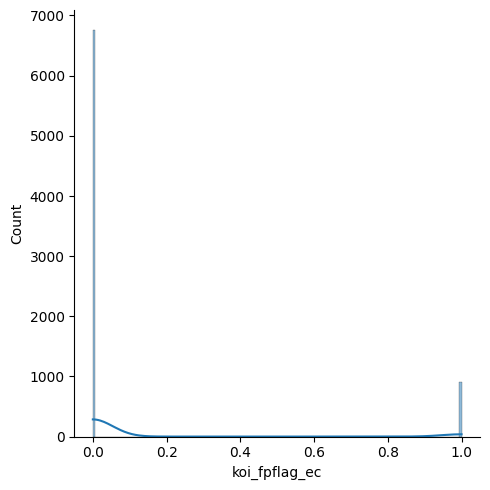

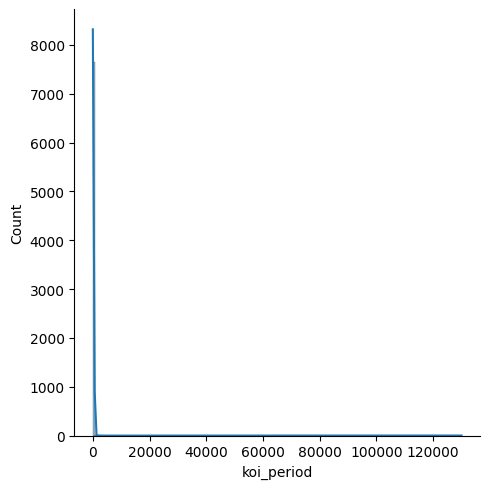

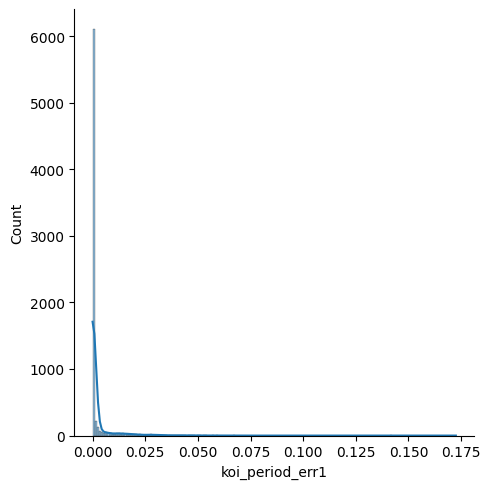

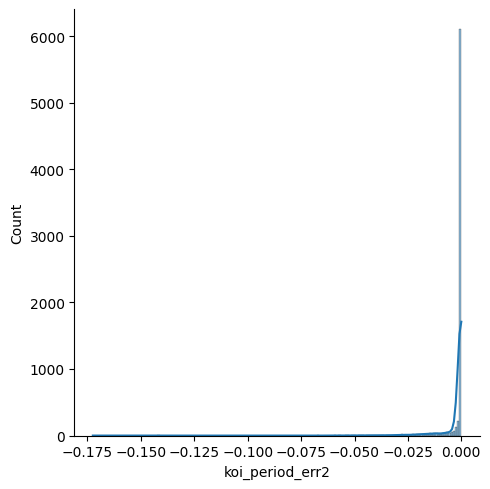

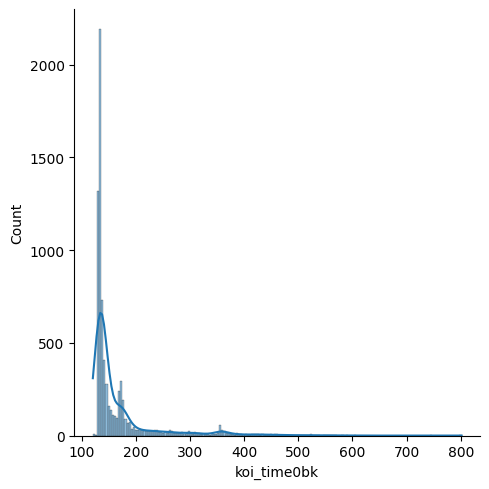

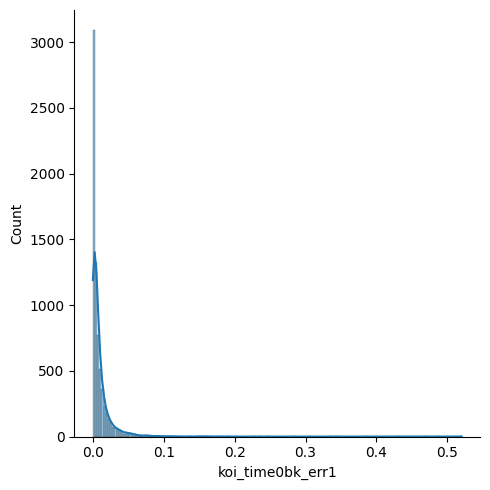

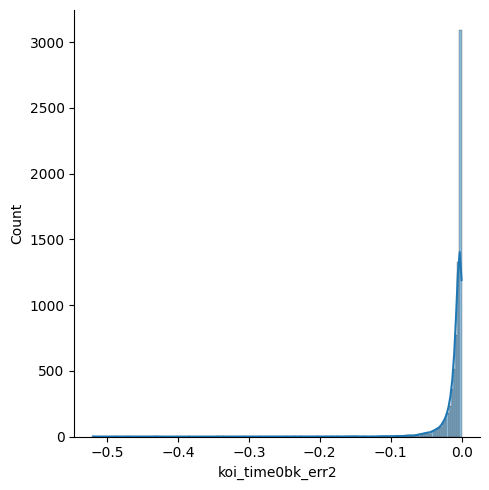

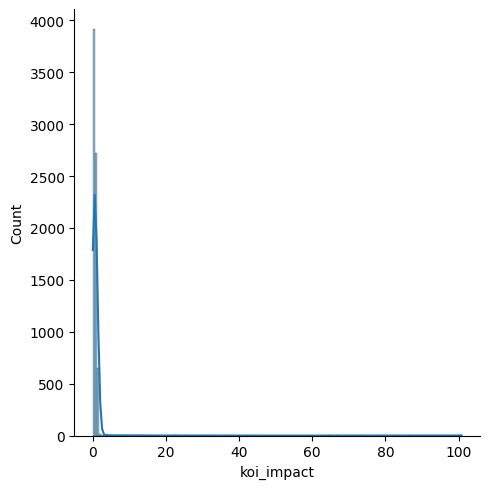

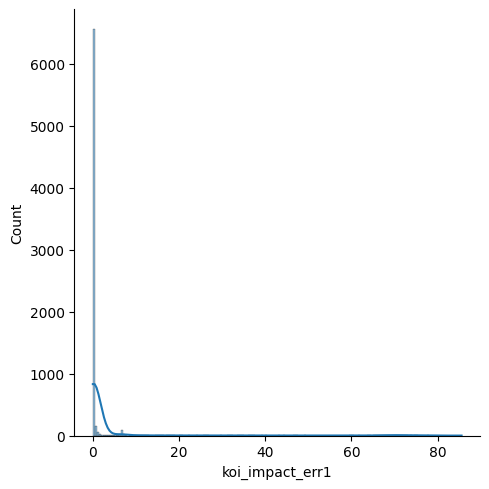

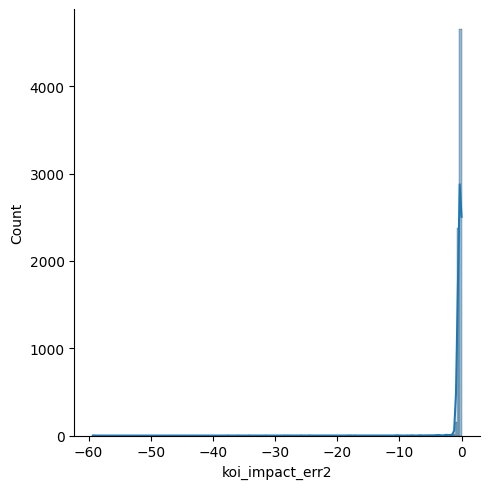

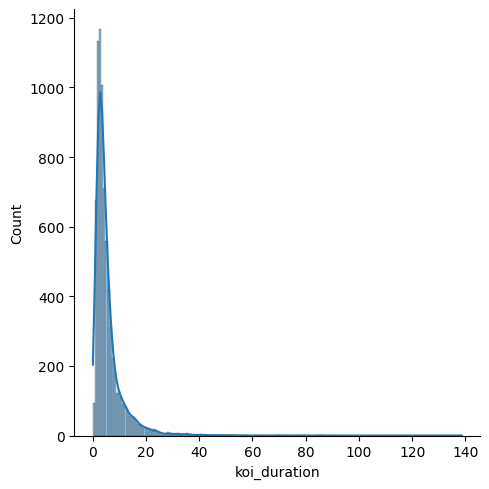

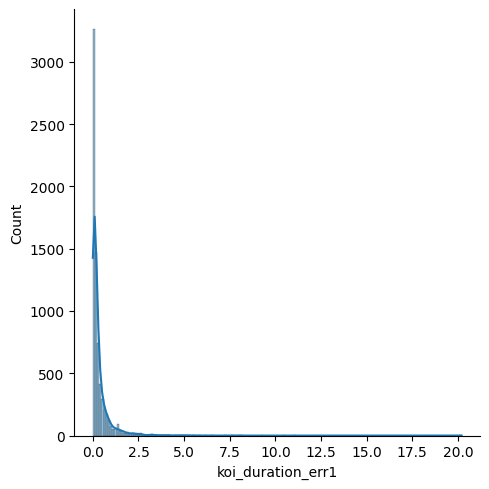

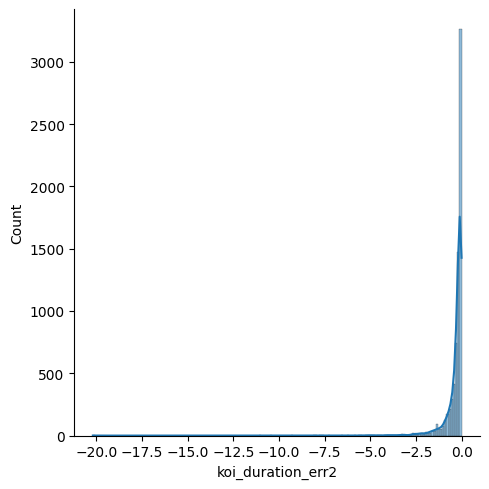

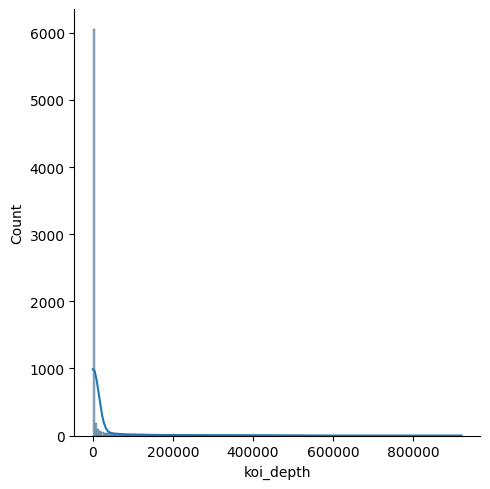

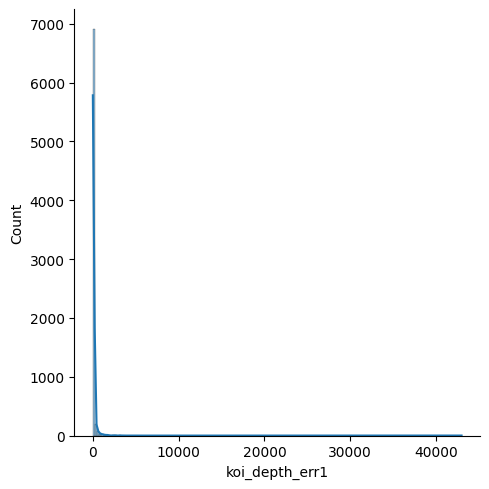

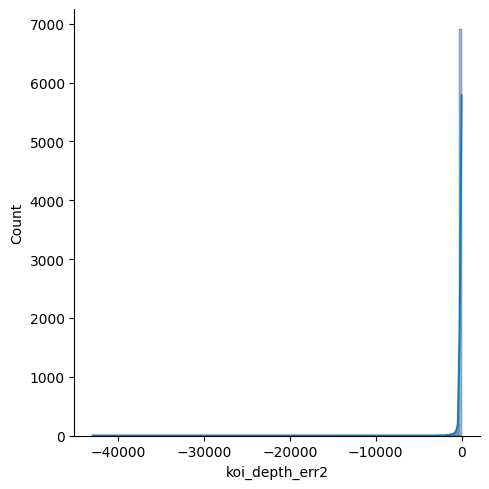

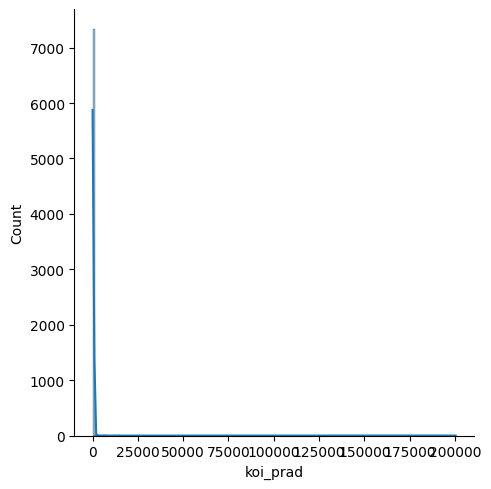

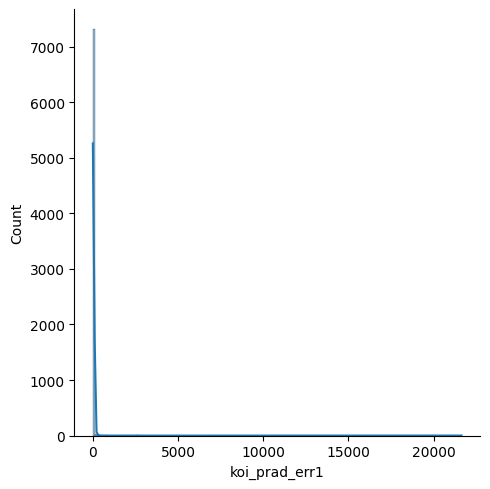

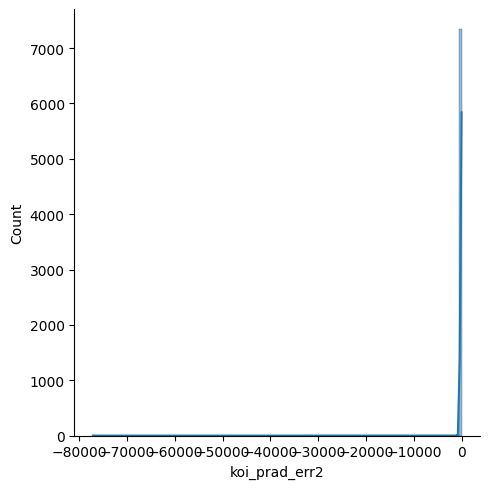

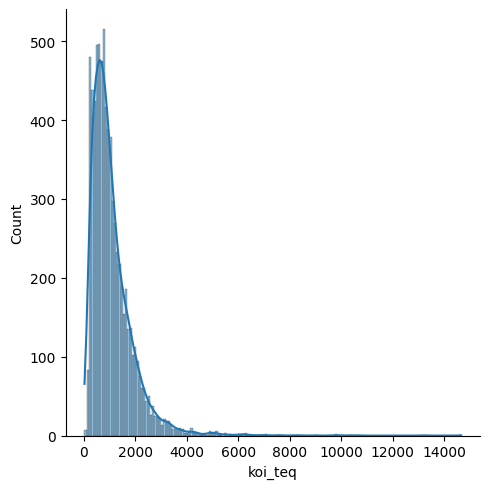

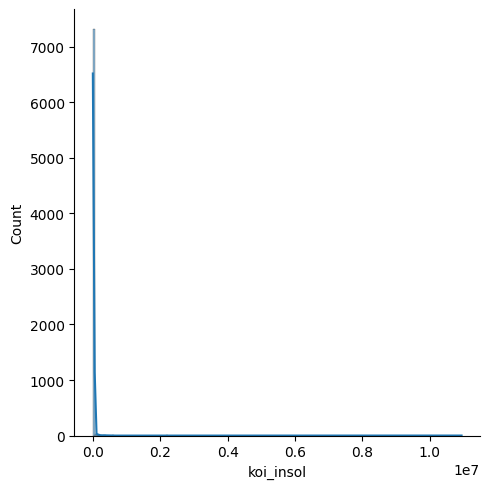

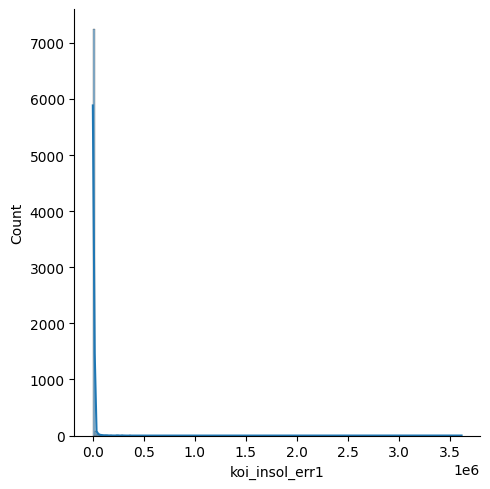

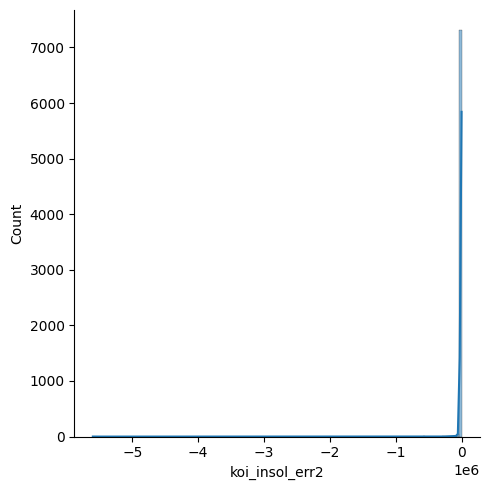

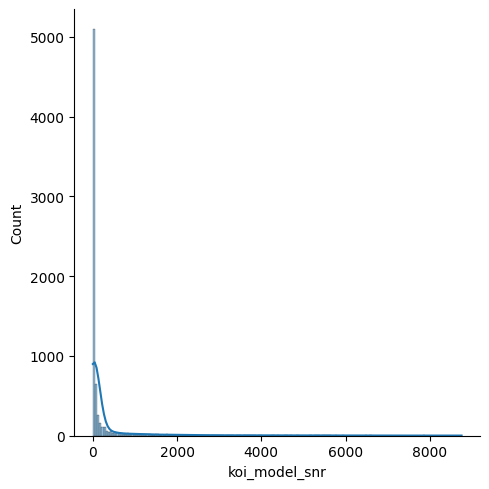

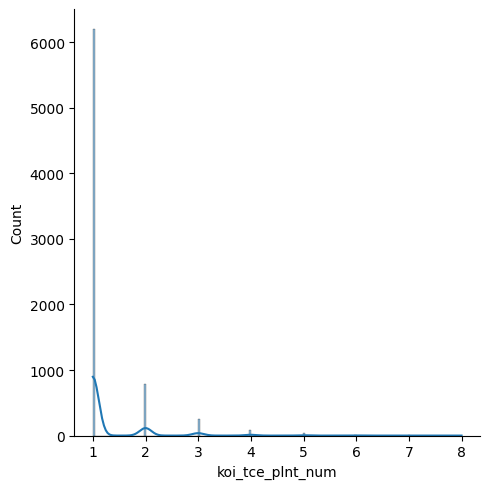

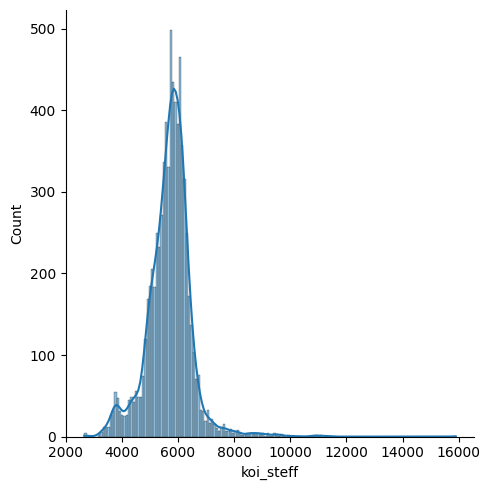

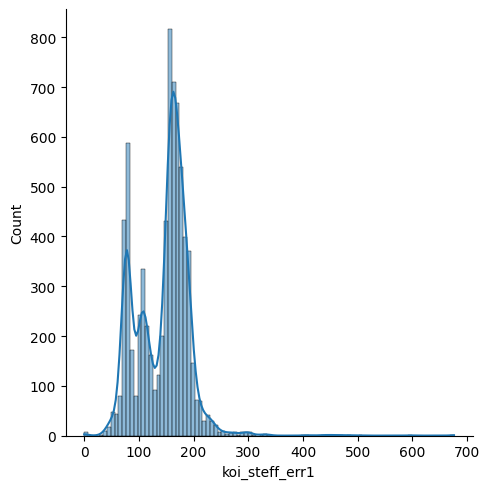

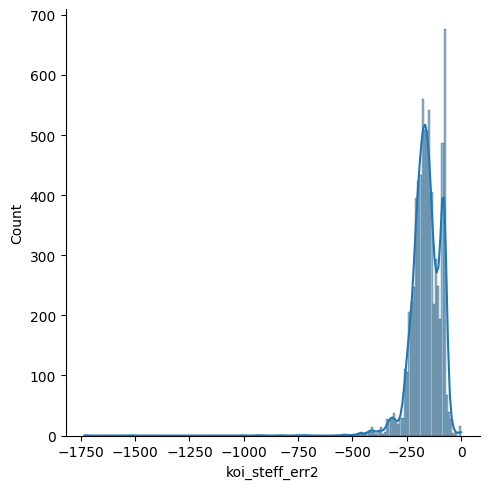

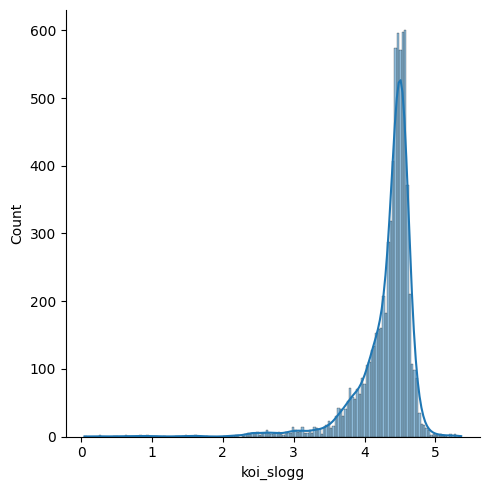

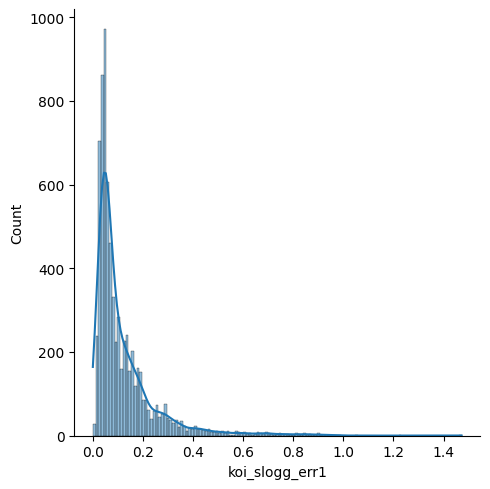

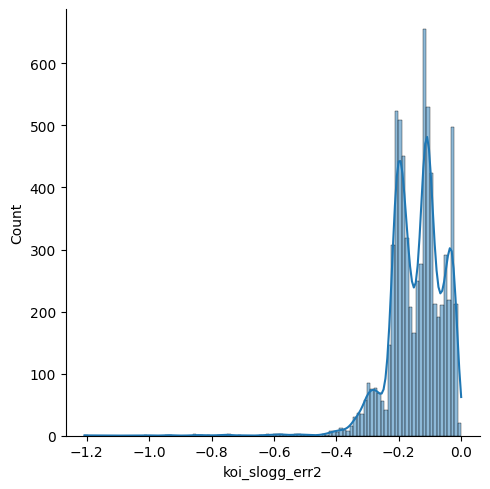

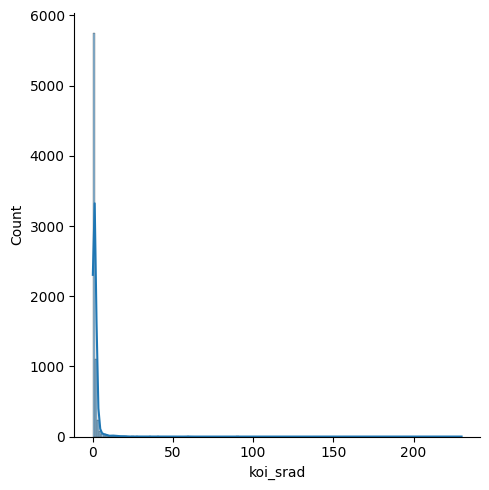

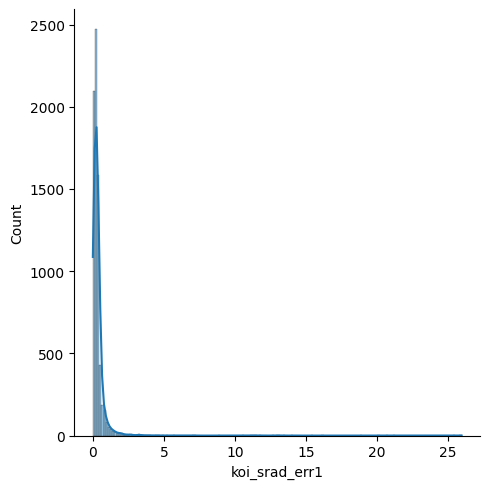

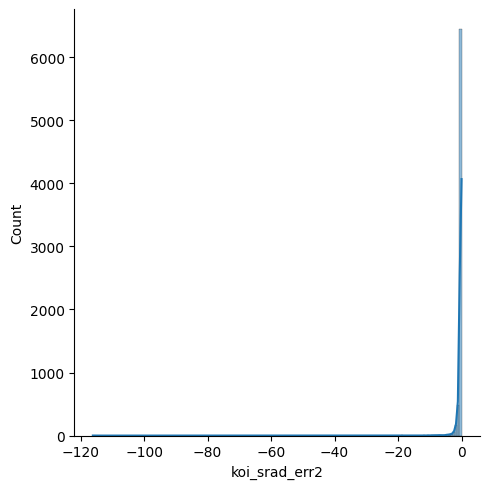

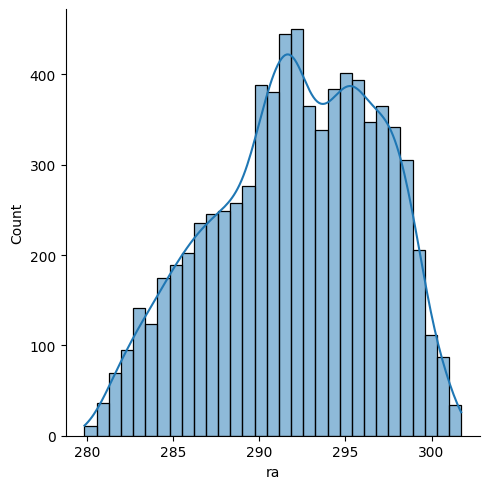

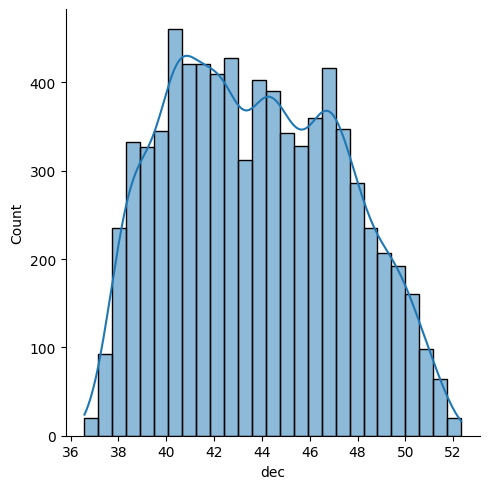

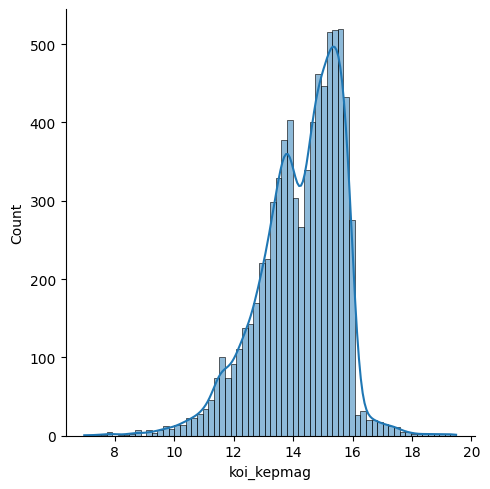

In [82]:
for i in numeric_columns:
    sns.displot(X_train[i], kde=True)


Based on the distribution and box plots, outlier correction is applied only to non-error columns with relatively few outliers, since error magnitudes vary with instrument precision and this dataset concerns distant astronomical objects measured with limited technology. The affected columns are capped using a percentile-based method, selected according to the observed distributions.

In [83]:
outlier_removal=['koi_period','koi_depth','koi_prad','koi_teq','koi_insol','koi_slogg','koi_srad']

In [84]:
for i in outlier_removal:
    # we will remove the 99th percentile 
    upper_limit=X_train[i].quantile(0.99)
    X_train[i] =np.where(X_train[i]>=upper_limit,
             upper_limit,
             X_train[i])
    
    

In [85]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7651 entries, 8117 to 7270
Data columns (total 41 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   koi_fpflag_nt      7651 non-null   int64  
 1   koi_fpflag_ss      7651 non-null   int64  
 2   koi_fpflag_co      7651 non-null   int64  
 3   koi_fpflag_ec      7651 non-null   int64  
 4   koi_period         7651 non-null   float64
 5   koi_period_err1    7283 non-null   float64
 6   koi_period_err2    7283 non-null   float64
 7   koi_time0bk        7651 non-null   float64
 8   koi_time0bk_err1   7283 non-null   float64
 9   koi_time0bk_err2   7283 non-null   float64
 10  koi_impact         7358 non-null   float64
 11  koi_impact_err1    7283 non-null   float64
 12  koi_impact_err2    7283 non-null   float64
 13  koi_duration       7651 non-null   float64
 14  koi_duration_err1  7283 non-null   float64
 15  koi_duration_err2  7283 non-null   float64
 16  koi_depth          7358 no

<Axes: xlabel='koi_tce_delivname', ylabel='Count'>

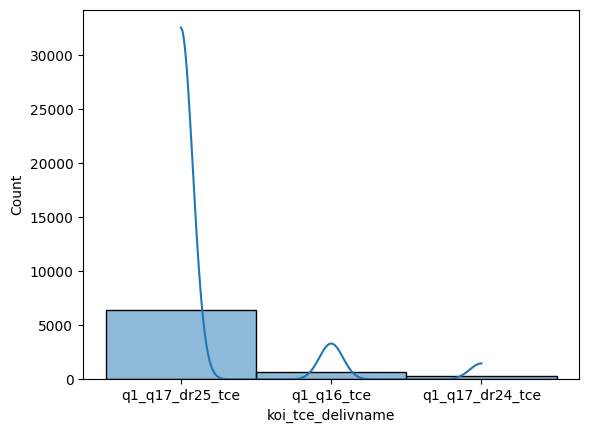

In [86]:
sns.histplot(X_train['koi_tce_delivname'], kde=True)


In [87]:
X_train.loc[X_train['koi_tce_delivname'].isnull(),'koi_tce_delivname']=(X_train['koi_tce_delivname'].dropna()).sample(X_train['koi_tce_delivname'].isnull().sum()).values


In [88]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7651 entries, 8117 to 7270
Data columns (total 41 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   koi_fpflag_nt      7651 non-null   int64  
 1   koi_fpflag_ss      7651 non-null   int64  
 2   koi_fpflag_co      7651 non-null   int64  
 3   koi_fpflag_ec      7651 non-null   int64  
 4   koi_period         7651 non-null   float64
 5   koi_period_err1    7283 non-null   float64
 6   koi_period_err2    7283 non-null   float64
 7   koi_time0bk        7651 non-null   float64
 8   koi_time0bk_err1   7283 non-null   float64
 9   koi_time0bk_err2   7283 non-null   float64
 10  koi_impact         7358 non-null   float64
 11  koi_impact_err1    7283 non-null   float64
 12  koi_impact_err2    7283 non-null   float64
 13  koi_duration       7651 non-null   float64
 14  koi_duration_err1  7283 non-null   float64
 15  koi_duration_err2  7283 non-null   float64
 16  koi_depth          7358 no

<Axes: xlabel='koi_tce_delivname', ylabel='Count'>

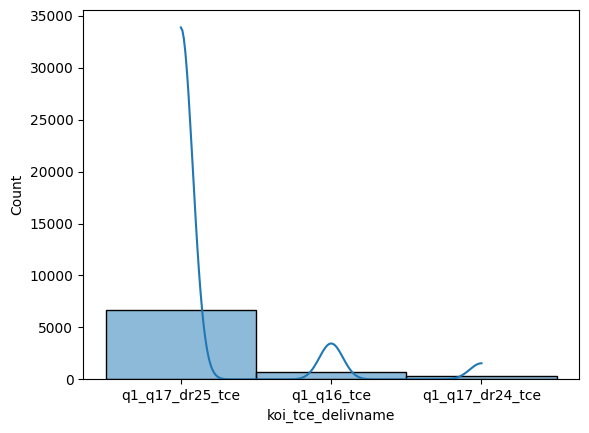

In [89]:
sns.histplot(X_train['koi_tce_delivname'], kde=True)


Following random sample imputation, the distribution of the affected column remains consistent with its original form.

The next step is to review summary statistics and remove columns found statistically unnecessary based on hypothesis testing.

In [90]:
from scipy.stats import f_oneway


In [91]:
X_train_hyp=X_train.copy(deep=True)
columns_req=X_train_hyp.columns
print(columns_req)


Index(['koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec',
       'koi_period', 'koi_period_err1', 'koi_period_err2', 'koi_time0bk',
       'koi_time0bk_err1', 'koi_time0bk_err2', 'koi_impact', 'koi_impact_err1',
       'koi_impact_err2', 'koi_duration', 'koi_duration_err1',
       'koi_duration_err2', 'koi_depth', 'koi_depth_err1', 'koi_depth_err2',
       'koi_prad', 'koi_prad_err1', 'koi_prad_err2', 'koi_teq', 'koi_insol',
       'koi_insol_err1', 'koi_insol_err2', 'koi_model_snr', 'koi_tce_plnt_num',
       'koi_tce_delivname', 'koi_steff', 'koi_steff_err1', 'koi_steff_err2',
       'koi_slogg', 'koi_slogg_err1', 'koi_slogg_err2', 'koi_srad',
       'koi_srad_err1', 'koi_srad_err2', 'ra', 'dec', 'koi_kepmag'],
      dtype='object')


In [92]:
column_numeric=columns_req.drop([
       'koi_tce_delivname'])

In [93]:
X_train_hyp.drop(['koi_tce_delivname'],axis=1,inplace=True)

In [94]:
pipeline_hyp=Pipeline([
('imputer', KNNImputer(n_neighbors=3)),
('scaling', StandardScaler())
])

scaling_transform=ColumnTransformer(transformers=[
('num_pip', pipeline_hyp, X_train_hyp.columns)
],remainder='passthrough')

X_train_hyp=scaling_transform.fit_transform(X_train_hyp)


In [95]:
accepted_columns=[]
new_column=X_train_hyp.columns
for i in new_column:
    group1=X_train_hyp.loc[y_train=='CONFIRMED' ,i]
    group2=X_train_hyp.loc[y_train=='FALSE POSITIVE',i]
    group3=X_train_hyp.loc[y_train=='CANDIDATE' ,i]
    f_statistic, p_value = f_oneway(group1, group2, group3)

    print(f"F-statistic {i} : {f_statistic}")
    print(f"P-value- {i} : {p_value}")
    if(p_value<0.05):
        accepted_columns.append(i)

F-statistic num_pip__koi_fpflag_nt : 981.8488685777509
P-value- num_pip__koi_fpflag_nt : 0.0
F-statistic num_pip__koi_fpflag_ss : 1202.1525963378317
P-value- num_pip__koi_fpflag_ss : 0.0
F-statistic num_pip__koi_fpflag_co : 1046.1020395214605
P-value- num_pip__koi_fpflag_co : 0.0
F-statistic num_pip__koi_fpflag_ec : 523.7753948189361
P-value- num_pip__koi_fpflag_ec : 6.531228174288797e-214
F-statistic num_pip__koi_period : 105.77554363176442
P-value- num_pip__koi_period : 4.854314404007775e-46
F-statistic num_pip__koi_period_err1 : 76.00850372579144
P-value- num_pip__koi_period_err1 : 2.0592471987738818e-33
F-statistic num_pip__koi_period_err2 : 76.00850372579144
P-value- num_pip__koi_period_err2 : 2.0592471987738818e-33
F-statistic num_pip__koi_time0bk : 21.541927072281684
P-value- num_pip__koi_time0bk : 4.685035716298767e-10
F-statistic num_pip__koi_time0bk_err1 : 90.26546711187613
P-value- num_pip__koi_time0bk_err1 : 1.793618717067944e-39
F-statistic num_pip__koi_time0bk_err2 : 90.2

Under the ANOVA framework, the null hypothesis (H0) holds when p > 0.05; when p < 0.05, H0 is rejected in favor of the alternative hypothesis (H1), indicating the feature is statistically significant. 

In [96]:
print(accepted_columns)

['num_pip__koi_fpflag_nt', 'num_pip__koi_fpflag_ss', 'num_pip__koi_fpflag_co', 'num_pip__koi_fpflag_ec', 'num_pip__koi_period', 'num_pip__koi_period_err1', 'num_pip__koi_period_err2', 'num_pip__koi_time0bk', 'num_pip__koi_time0bk_err1', 'num_pip__koi_time0bk_err2', 'num_pip__koi_impact', 'num_pip__koi_impact_err1', 'num_pip__koi_duration', 'num_pip__koi_duration_err1', 'num_pip__koi_duration_err2', 'num_pip__koi_depth', 'num_pip__koi_depth_err1', 'num_pip__koi_depth_err2', 'num_pip__koi_prad', 'num_pip__koi_prad_err1', 'num_pip__koi_teq', 'num_pip__koi_insol', 'num_pip__koi_insol_err1', 'num_pip__koi_model_snr', 'num_pip__koi_tce_plnt_num', 'num_pip__koi_steff', 'num_pip__koi_steff_err1', 'num_pip__koi_steff_err2', 'num_pip__koi_slogg', 'num_pip__koi_slogg_err1', 'num_pip__koi_slogg_err2', 'num_pip__koi_srad', 'num_pip__koi_srad_err1', 'num_pip__koi_srad_err2', 'num_pip__ra', 'num_pip__dec', 'num_pip__koi_kepmag']


In [97]:
len(accepted_columns)

37

37 columns met the p < 0.05 threshold and were retained; this count will also be used as the k value for SelectKBest in the modeling pipeline.

The chi-squared test is applied next, for the categorical feature.

In [98]:
from scipy.stats import chi2_contingency

In [99]:
chi2,p,dof,expected=chi2_contingency(
    pd.crosstab(
        X_train['koi_tce_delivname'],
        y_train
    )
)
print("Chi_squared:" , chi2)
print("P-value:" , p)
        

Chi_squared: 362.9366718677515
P-value: 2.8215683501865863e-77


The resulting p-value is above 0.05, providing statistical evidence that the feature is not at all significantly associated with the target variable.

In [100]:
X_train.drop(['koi_tce_delivname'], axis=1, inplace=True)

New features will be engineered from the existing error columns. Rather than leaving each error pair (err1, err2) as an isolated, seemingly unrelated value, they will be combined into an absolute uncertainty measure (err1 - err2) and a relative uncertainty measure (normalized by the corresponding feature value), giving the model more directly interpretable signal.|

In [101]:
error_columns=[
       'koi_period_err1',
       'koi_period_err2', 
       'koi_time0bk_err1', 
       'koi_time0bk_err2',
       'koi_impact_err1',
       'koi_impact_err2', 
       'koi_duration_err1', 
       'koi_duration_err2',
       'koi_depth_err1',
       'koi_depth_err2',
       'koi_prad_err1', 
       'koi_prad_err2',
       'koi_insol_err1',
       'koi_insol_err2', 
       'koi_steff_err1', 
       'koi_steff_err2',
       'koi_slogg_err1',
       'koi_slogg_err2', 
       'koi_srad_err1', 
       'koi_srad_err2']


In [102]:
eps = 1e-8
X_train['koi_period_uncertainity']=X_train['koi_period_err1']-X_train['koi_period_err2']
X_train['koi_period_uncertainity_rel']=(X_train['koi_period_err1']-X_train['koi_period_err2'])/(X_train['koi_period']+eps)

X_train['koi_time0bk_uncertainity']=X_train['koi_time0bk_err1']-X_train['koi_time0bk_err2']
X_train['koi_time0bk_uncertainity_rel']=(X_train['koi_time0bk_err1']-X_train['koi_time0bk_err2'])/(X_train['koi_time0bk']+eps)

X_train['koi_impact_uncertainity']=X_train['koi_impact_err1']-X_train['koi_impact_err2']
X_train['koi_impact_uncertainity_rel']=(X_train['koi_impact_err1']-X_train['koi_impact_err2'])/(X_train['koi_impact']+eps)

X_train['koi_duration_uncertainity']=X_train['koi_duration_err1']-X_train['koi_duration_err2']
X_train['koi_duration_uncertainity_rel']=(X_train['koi_duration_err1']-X_train['koi_duration_err2'])/(X_train['koi_duration']+eps)


X_train['koi_depth_uncertainity']=X_train['koi_depth_err1']-X_train['koi_depth_err2']
X_train['koi_depth_uncertainity_rel']=(X_train['koi_depth_err1']-X_train['koi_depth_err2'])/(X_train['koi_depth']+eps)

X_train['koi_prad_uncertainity']=X_train['koi_prad_err1']-X_train['koi_prad_err2']
X_train['koi_prad_uncertainity_rel']=(X_train['koi_prad_err1']-X_train['koi_prad_err2'])/(X_train['koi_prad']+eps)

X_train['koi_insol_uncertainity']=X_train['koi_insol_err1']-X_train['koi_insol_err2']
X_train['koi_insol_uncertainity_rel']=(X_train['koi_insol_err1']-X_train['koi_insol_err2'])/(X_train['koi_insol']+eps)

X_train['koi_steff_uncertainity']=X_train['koi_steff_err1']-X_train['koi_steff_err2']
X_train['koi_steff_uncertainity_rel']=(X_train['koi_steff_err1']-X_train['koi_steff_err2'])/(X_train['koi_steff']+eps)

X_train['koi_slogg_uncertainity']=X_train['koi_slogg_err1']-X_train['koi_slogg_err2']
X_train['koi_slogg_uncertainity_rel']=(X_train['koi_slogg_err1']-X_train['koi_slogg_err2'])/(X_train['koi_slogg']+eps)

X_train['koi_srad_uncertainity']=X_train['koi_srad_err1']-X_train['koi_srad_err2']
X_train['koi_srad_uncertainity_rel']=(X_train['koi_srad_err1']-X_train['koi_srad_err2'])/(X_train['koi_srad']+eps)

X_train.drop(error_columns, axis=1, inplace=True)
    

In [103]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7651 entries, 8117 to 7270
Data columns (total 40 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   koi_fpflag_nt                  7651 non-null   int64  
 1   koi_fpflag_ss                  7651 non-null   int64  
 2   koi_fpflag_co                  7651 non-null   int64  
 3   koi_fpflag_ec                  7651 non-null   int64  
 4   koi_period                     7651 non-null   float64
 5   koi_time0bk                    7651 non-null   float64
 6   koi_impact                     7358 non-null   float64
 7   koi_duration                   7651 non-null   float64
 8   koi_depth                      7358 non-null   float64
 9   koi_prad                       7358 non-null   float64
 10  koi_teq                        7358 non-null   float64
 11  koi_insol                      7396 non-null   float64
 12  koi_model_snr                  7358 non-null   flo

In [104]:


pipeline1=Pipeline([
('imputer', KNNImputer(n_neighbors=3)),
('scaling', StandardScaler())
])

scaling_transform=ColumnTransformer(transformers=[
('num_pip', pipeline1, X_train.columns)
],remainder='passthrough')

In [105]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier


models_and_params = {
    'LogisticRegression': {
        'model': LogisticRegression(max_iter=1000),
        'params': {
            'model__C': [0.01, 0.1, 1, 10]
        }
    },
    'RandomForest': {
        'model': RandomForestClassifier(),
        'params': {
            'model__n_estimators': [100, 200],
            'model__max_depth': [None, 10, 20]
        }
    },
    'GradientBoosting': {
        'model': GradientBoostingClassifier(),
        'params': {
            'model__n_estimators': [100, 200],
            'model__learning_rate': [0.01, 0.1]
        }
    },
    'SVC': {
        'model': SVC(),
        'params': {
            'model__C': [0.1, 1, 10],
            'model__kernel': ['rbf', 'linear']
        }
    },
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {
            'model__n_neighbors': [3, 5, 7, 9]
        }
    }
}

In [106]:
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectKBest, f_classif

results=[]
for name,config in models_and_params.items():
    pipeline=Pipeline([
        ('preprocessing', scaling_transform),
        ('feature_selection', SelectKBest(k=37)),
        ('model', config['model'])
    ])
    grid=GridSearchCV(pipeline, config['params'], cv=5, scoring='f1_macro', n_jobs=-1)
    grid.fit(X_train,y_train)
    results.append({
        'model': name,
        'best_score': grid.best_score_,
        'best_params': grid.best_params_,
        'best_estimator': grid.best_estimator_
    })
    print(f"{name}: {grid.best_score_:.4f}")
results_df = pd.DataFrame(results).sort_values('best_score', ascending=False)
print(results_df[['model', 'best_score', 'best_params']])

LogisticRegression: 0.8603
RandomForest: 0.8578
GradientBoosting: 0.8703
SVC: 0.8602
KNN: 0.7916
                model  best_score  \
2    GradientBoosting    0.870251   
0  LogisticRegression    0.860265   
3                 SVC    0.860191   
1        RandomForest    0.857771   
4                 KNN    0.791604   

                                         best_params  
2  {'model__learning_rate': 0.1, 'model__n_estima...  
0                                   {'model__C': 10}  
3        {'model__C': 10, 'model__kernel': 'linear'}  
1  {'model__max_depth': 20, 'model__n_estimators'...  
4                          {'model__n_neighbors': 9}  


In [107]:
results

[{'model': 'LogisticRegression',
  'best_score': np.float64(0.8602646721984872),
  'best_params': {'model__C': 10},
  'best_estimator': Pipeline(steps=[('preprocessing',
                   ColumnTransformer(remainder='passthrough',
                                     transformers=[('num_pip',
                                                    Pipeline(steps=[('imputer',
                                                                     KNNImputer(n_neighbors=3)),
                                                                    ('scaling',
                                                                     StandardScaler())]),
                                                    Index(['koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec',
         'koi_period', 'koi_time0bk', 'koi_impact', 'koi_duration', 'koi_depth',
         'koi_prad', 'koi_teq', 'koi_i...
         'koi_prad_uncertainity', 'koi_prad_uncertainity_rel',
         'koi_insol_uncertainity', 'koi_insol

The GridSearchCV results are stored as a list of dictionaries, each containing the model name, best cross-validated score, best hyperparameters, and the corresponding fitted estimator.

In [108]:
eps = 1e-8
X_test['koi_period_uncertainity']=X_test['koi_period_err1']-X_test['koi_period_err2']
X_test['koi_period_uncertainity_rel']=(X_test['koi_period_err1']-X_test['koi_period_err2'])/(X_test['koi_period']+eps)

X_test['koi_time0bk_uncertainity']=X_test['koi_time0bk_err1']-X_test['koi_time0bk_err2']
X_test['koi_time0bk_uncertainity_rel']=(X_test['koi_time0bk_err1']-X_test['koi_time0bk_err2'])/(X_test['koi_time0bk']+eps)

X_test['koi_impact_uncertainity']=X_test['koi_impact_err1']-X_test['koi_impact_err2']
X_test['koi_impact_uncertainity_rel']=(X_test['koi_impact_err1']-X_test['koi_impact_err2'])/(X_test['koi_impact']+eps)

X_test['koi_duration_uncertainity']=X_test['koi_duration_err1']-X_test['koi_duration_err2']
X_test['koi_duration_uncertainity_rel']=(X_test['koi_duration_err1']-X_test['koi_duration_err2'])/(X_test['koi_duration']+eps)


X_test['koi_depth_uncertainity']=X_test['koi_depth_err1']-X_test['koi_depth_err2']
X_test['koi_depth_uncertainity_rel']=(X_test['koi_depth_err1']-X_test['koi_depth_err2'])/(X_test['koi_depth']+eps)

X_test['koi_prad_uncertainity']=X_test['koi_prad_err1']-X_test['koi_prad_err2']
X_test['koi_prad_uncertainity_rel']=(X_test['koi_prad_err1']-X_test['koi_prad_err2'])/(X_test['koi_prad']+eps)

X_test['koi_insol_uncertainity']=X_test['koi_insol_err1']-X_test['koi_insol_err2']
X_test['koi_insol_uncertainity_rel']=(X_test['koi_insol_err1']-X_test['koi_insol_err2'])/(X_test['koi_insol']+eps)

X_test['koi_steff_uncertainity']=X_test['koi_steff_err1']-X_test['koi_steff_err2']
X_test['koi_steff_uncertainity_rel']=(X_test['koi_steff_err1']-X_test['koi_steff_err2'])/(X_test['koi_steff']+eps)

X_test['koi_slogg_uncertainity']=X_test['koi_slogg_err1']-X_test['koi_slogg_err2']
X_test['koi_slogg_uncertainity_rel']=(X_test['koi_slogg_err1']-X_test['koi_slogg_err2'])/(X_test['koi_slogg']+eps)

X_test['koi_srad_uncertainity']=X_test['koi_srad_err1']-X_test['koi_srad_err2']
X_test['koi_srad_uncertainity_rel']=(X_test['koi_srad_err1']-X_test['koi_srad_err2'])/(X_test['koi_srad']+eps)

X_test.drop(error_columns, axis=1, inplace=True)

In [109]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
for result in results:
    model = result['best_estimator']
    y_pred = model.predict(X_test)
    print("="*50)
    print(result['model'])
    print("Accuracy:",accuracy_score(y_test,y_pred))
    print("Macro F1:", f1_score(y_test,y_pred, average="macro"))
    print(classification_report(y_test,y_pred))
    

LogisticRegression
Accuracy: 0.8855201254573968
Macro F1: 0.8476334406799099
                precision    recall  f1-score   support

     CANDIDATE       0.81      0.71      0.76       451
     CONFIRMED       0.76      0.87      0.81       454
FALSE POSITIVE       0.98      0.97      0.98      1008

      accuracy                           0.89      1913
     macro avg       0.85      0.85      0.85      1913
  weighted avg       0.89      0.89      0.88      1913

RandomForest
Accuracy: 0.8907475169890224
Macro F1: 0.8551300567511199
                precision    recall  f1-score   support

     CANDIDATE       0.81      0.74      0.77       451
     CONFIRMED       0.80      0.84      0.82       454
FALSE POSITIVE       0.97      0.98      0.97      1008

      accuracy                           0.89      1913
     macro avg       0.86      0.85      0.86      1913
  weighted avg       0.89      0.89      0.89      1913

GradientBoosting
Accuracy: 0.8996340825927862
Macro F1: 0.8668

**Results and Analysis**

Across all five models evaluated on the held-out test set, Gradient Boosting achieved the strongest overall performance, with an accuracy of 89.96% and a macro F1-score of 0.867, marginally ahead of Random Forest (88.97%) and SVC (88.87%). Logistic Regression performed comparably despite being the simplest model in the comparison, while KNN trailed the group, indicating that the decision boundaries in this feature space are not well captured by a purely distance-based approach.

A consistent pattern emerges across every model when the per-class metrics are examined: FALSE POSITIVE is classified with high reliability (precision and recall both in the 0.96–0.98 range for all models), whereas CANDIDATE and CONFIRMED show substantially more confusion with each other, with CANDIDATE recall in particular falling as low as 0.62–0.78 depending on the model. This is consistent with the underlying domain reality: a FALSE POSITIVE typically corresponds to a clearly identifiable artifact (e.g., an eclipsing binary or instrumental signal), while the distinction between a CANDIDATE and a CONFIRMED planet is often a matter of degree — a CANDIDATE frequently represents a transit signal that has not yet accumulated sufficient follow-up evidence to be promoted to CONFIRMED, rather than a physically distinct category. The models are, in effect, being asked to separate two classes that sit on a continuum rather than a hard boundary.

This suggests that the current accuracy ceiling is not primarily a function of model choice, but of the inherent overlap between two of the three target classes. Improvements from here are more likely to come from addressing that overlap directly — through class-imbalance-aware training (e.g., class weighting), richer feature engineering targeted specifically at the CANDIDATE/CONFIRMED boundary, or ensembling the strongest models — than from further tuning of any single algorithm in isolation.

**Conclusion**

This project demonstrates an end-to-end classification pipeline for identifying exoplanet dispositions from Kepler mission data, incorporating statistically grounded feature selection, leakage-safe preprocessing, and engineered uncertainty features derived from raw measurement errors. The final Gradient Boosting model achieves approximately 90% test accuracy and a macro F1-score of 0.87, with near-perfect separation of false positives and the primary residual error concentrated in the genuinely ambiguous CANDIDATE–CONFIRMED boundary — a limitation rooted in the data itself rather than in the modeling approach. The pipeline is structured to be extended straightforwardly with additional models, feature sets, or imbalance-handling strategies in future iterations.

## Deployment, SHAP Analysis, and Model Export

The cells below are intentionally added **after the original workflow**. The existing analysis, variables, model-selection process, and notebook structure are preserved.

The deployment section reproduces the preprocessing that occurs outside the fitted sklearn pipeline:
- the same 99th-percentile clipping calculated from the original training split
- the same uncertainty-feature engineering
- removal of the same error columns

The fitted estimator stored in `results` already contains:
- KNN imputation
- StandardScaler
- SelectKBest(k=37)
- the selected classifier

This allows the trained model to be exported without rewriting the earlier notebook.


In [110]:
# ============================================================
# DEPLOYMENT SETUP
# ============================================================

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

# Select the best model from the existing `results` variable.
best_result = max(results, key=lambda x: x["best_score"])
best_model = best_result["best_estimator"]

print("Best model:", best_result["model"])
print("Best CV Macro F1:", best_result["best_score"])
print("Best parameters:", best_result["best_params"])


Best model: GradientBoosting
Best CV Macro F1: 0.870251055186284
Best parameters: {'model__learning_rate': 0.1, 'model__n_estimators': 200}


In [112]:
# ============================================================
# RECREATE THE TRAINING-SPLIT OUTLIER CAPS FOR DEPLOYMENT
# ============================================================
#
# In the original notebook, the 99th-percentile caps were applied
# directly to X_train but were not stored in a dictionary.
#
# For deployment, we recreate those exact caps from the same
# original train/test split. This does not change the existing
# notebook variables.

deployment_raw_df = pd.read_csv("../data/dataset.csv")

deployment_df = deployment_raw_df.copy()

# Match the original notebook's column removals before splitting.
deployment_df.drop(
    deployment_df.columns[[0, 1, 30, 31]],
    axis=1,
    inplace=True
)

deployment_df.drop(
    ["kepler_name", "koi_pdisposition", "koi_score"],
    axis=1,
    inplace=True
)

deployment_df.drop(
    ["kepoi_name"],
    axis=1,
    inplace=True
)

deployment_X,_,deployment_y,_ = train_test_split(
    deployment_df.drop(["koi_disposition"], axis=1),
    deployment_df["koi_disposition"],
    random_state=42,
    test_size=0.2
)

deployment_outlier_caps = {}

for feature in outlier_removal:
    deployment_outlier_caps[feature] = deployment_X[feature].quantile(0.99)

print("Deployment outlier caps:")
print(deployment_outlier_caps)


Deployment outlier caps:
{'koi_period': np.float64(558.75109), 'koi_depth': np.float64(415461.00000000023), 'koi_prad': np.float64(370.7738000000011), 'koi_teq': np.float64(4179.290000000001), 'koi_insol': np.float64(72806.12850000004), 'koi_slogg': np.float64(4.813), 'koi_srad': np.float64(12.982470000000037)}


In [113]:
# ============================================================
# REUSABLE DEPLOYMENT FEATURE ENGINEERING
# ============================================================
#
# This reproduces cells 48, 73 and 82 for a NEW/raw observation.
# The original notebook cells are not modified.

deployment_error_columns = error_columns.copy()

def prepare_deployment_data(raw_input):
    data = raw_input.copy()

    # If a complete Kepler dataset row is supplied, reproduce the
    # same initial column removals used in the notebook.
    initial_drop = [
        "rowid",
        "kepid",
        "kepler_name",
        "koi_pdisposition",
        "koi_score",
        "kepoi_name"
    ]

    data.drop(columns=initial_drop, errors="ignore", inplace=True)

    # Target must never be supplied to the model.
    data.drop(columns=["koi_disposition"], errors="ignore", inplace=True)

    # Reproduce the training-time 99th-percentile clipping.
    for feature in outlier_removal:
        if feature in data.columns:
            data[feature] = np.where(
                data[feature] >= deployment_outlier_caps[feature],
                deployment_outlier_caps[feature],
                data[feature]
            )

    eps = 1e-8

    # Reproduce the uncertainty features from the notebook.
    uncertainty_pairs = [
        ("koi_period", "koi_period_err1", "koi_period_err2"),
        ("koi_time0bk", "koi_time0bk_err1", "koi_time0bk_err2"),
        ("koi_impact", "koi_impact_err1", "koi_impact_err2"),
        ("koi_duration", "koi_duration_err1", "koi_duration_err2"),
        ("koi_depth", "koi_depth_err1", "koi_depth_err2"),
        ("koi_prad", "koi_prad_err1", "koi_prad_err2"),
        ("koi_insol", "koi_insol_err1", "koi_insol_err2"),
        ("koi_steff", "koi_steff_err1", "koi_steff_err2"),
        ("koi_slogg", "koi_slogg_err1", "koi_slogg_err2"),
        ("koi_srad", "koi_srad_err1", "koi_srad_err2"),
    ]

    for feature, err1, err2 in uncertainty_pairs:
        data[f"{feature}_uncertainity"] = (
            data[err1] - data[err2]
        )
        data[f"{feature}_uncertainity_rel"] = (
            (data[err1] - data[err2])
            / (data[feature] + eps)
        )

    # Match cell 73: the original error columns are removed.
    data.drop(
        columns=deployment_error_columns,
        errors="ignore",
        inplace=True
    )

    # Match cell 70: categorical delivery-name feature is removed.
    data.drop(
        columns=["koi_tce_delivname"],
        errors="ignore",
        inplace=True
    )

    return data


print("Deployment preprocessing function created.")


Deployment preprocessing function created.


In [114]:
# ============================================================
# VERIFY THE EXPORTED MODEL ON THE EXISTING TEST SET
# ============================================================

# Use the already-prepared X_test from the original notebook.
deployment_test_predictions = best_model.predict(X_test)

deployment_accuracy = accuracy_score(
    y_test,
    deployment_test_predictions
)

deployment_macro_f1 = f1_score(
    y_test,
    deployment_test_predictions,
    average="macro"
)

print("Best model:", best_result["model"])
print("Test Accuracy:", deployment_accuracy)
print("Test Macro F1:", deployment_macro_f1)

print(
    classification_report(
        y_test,
        deployment_test_predictions
    )
)


Best model: GradientBoosting
Test Accuracy: 0.8996340825927862
Test Macro F1: 0.8668155031308514
                precision    recall  f1-score   support

     CANDIDATE       0.82      0.78      0.80       451
     CONFIRMED       0.80      0.85      0.82       454
FALSE POSITIVE       0.98      0.98      0.98      1008

      accuracy                           0.90      1913
     macro avg       0.87      0.87      0.87      1913
  weighted avg       0.90      0.90      0.90      1913



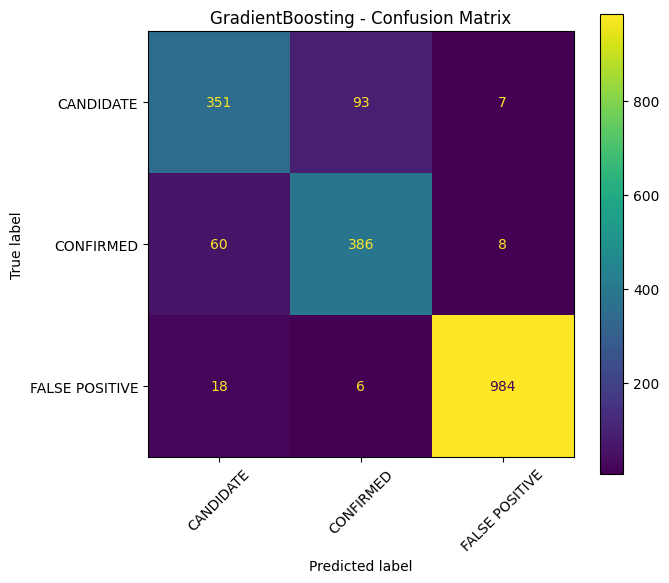

In [115]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

fig, ax = plt.subplots(figsize=(7, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    deployment_test_predictions,
    ax=ax,
    xticks_rotation=45
)

plt.title(f"{best_result['model']} - Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "confusion_matrix.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


,Model,CV Macro F1,Test Accuracy,Test Macro F1
2,GradientBoosting,0.870251,0.899634,0.866816
1,RandomForest,0.857771,0.890748,0.855130
3,SVC,0.860191,0.888657,0.851443
0,LogisticRegression,0.860265,0.885520,0.847633
4,KNN,0.791604,0.841610,0.793205


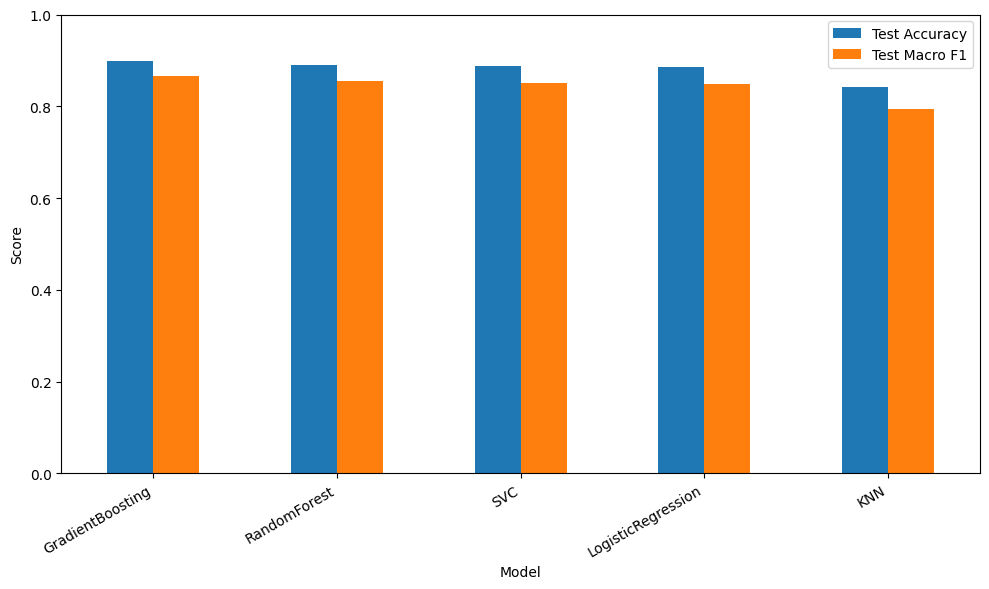

In [116]:
# ============================================================
# MODEL COMPARISON
# ============================================================

comparison_rows = []

for result in results:
    current_model = result["best_estimator"]
    current_pred = current_model.predict(X_test)

    comparison_rows.append({
        "Model": result["model"],
        "CV Macro F1": result["best_score"],
        "Test Accuracy": accuracy_score(y_test, current_pred),
        "Test Macro F1": f1_score(
            y_test,
            current_pred,
            average="macro"
        )
    })

deployment_comparison = (
    pd.DataFrame(comparison_rows)
    .sort_values("Test Macro F1", ascending=False)
)

display(deployment_comparison)

deployment_comparison.to_csv(
    "model_comparison.csv",
    index=False
)

ax = deployment_comparison.plot(
    x="Model",
    y=["Test Accuracy", "Test Macro F1"],
    kind="bar",
    figsize=(10, 6)
)

ax.set_ylabel("Score")
ax.set_ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.savefig(
    "model_comparison.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


In [119]:
# ============================================================
# SHAP ANALYSIS
# ============================================================

print("Classifier used:", type(classifier))

# Use a small representative sample so SHAP runs quickly
X_shap = X_train_selected.sample(
    min(100, len(X_train_selected)),
    random_state=42
)

# Use a small background dataset
X_background = X_train_selected.sample(
    min(50, len(X_train_selected)),
    random_state=42
)

print("Using SHAP PermutationExplainer...")

shap_explainer = shap.Explainer(
    classifier.predict_proba,
    X_background,
    algorithm="permutation"
)

shap_values = shap_explainer(
    X_shap
)

print("SHAP analysis complete.")
print("SHAP values shape:", shap_values.values.shape)

Classifier used: <class 'sklearn.ensemble._gb.GradientBoostingClassifier'>
Using SHAP PermutationExplainer...


PermutationExplainer explainer: 101it [00:31,  3.17it/s]                         

SHAP analysis complete.
SHAP values shape: (100, 37, 3)


SHAP array shape: (100, 37, 3)

Top SHAP Features:


,Feature,Mean Absolute SHAP
1,num_pip__koi_fpflag_ss,0.140746
2,num_pip__koi_fpflag_co,0.079304
0,num_pip__koi_fpflag_nt,0.070730
12,num_pip__koi_model_snr,0.053726
9,num_pip__koi_prad,0.049356
26,num_pip__koi_duration_uncertainity_rel,0.038257
3,num_pip__koi_fpflag_ec,0.019965
32,num_pip__koi_steff_uncertainity_rel,0.017255
7,num_pip__koi_duration,0.015658
8,num_pip__koi_depth,0.014391


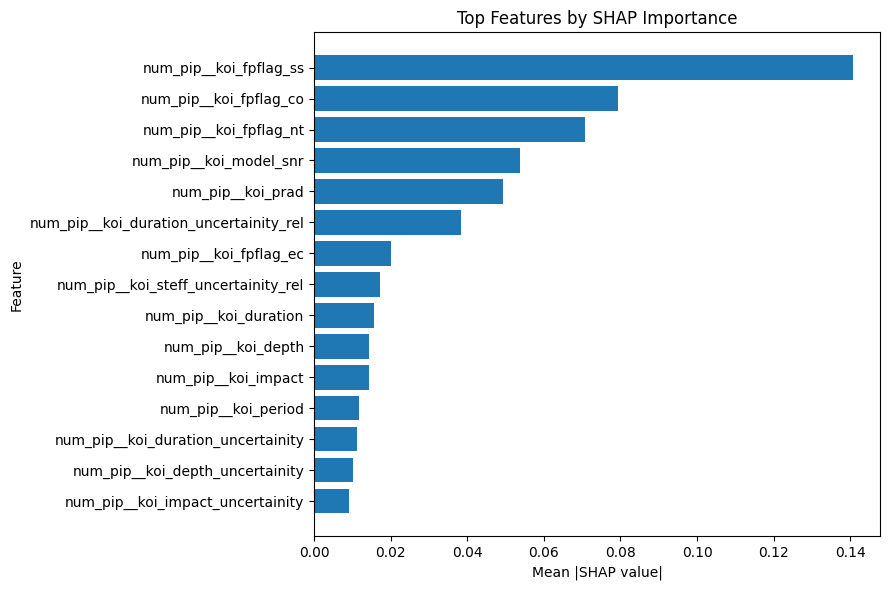

In [121]:
# ============================================================
# SHAP FEATURE IMPORTANCE
# ============================================================

# SHAP returns an Explanation object.
# We need its numerical .values array.
shap_array = np.asarray(shap_values.values)

print("SHAP array shape:", shap_array.shape)

# For multiclass classification:
# expected shape:
# (samples, features, classes)

if shap_array.ndim == 3:

    mean_abs_shap = np.mean(
        np.abs(shap_array),
        axis=(0, 2)
    )

else:

    mean_abs_shap = np.mean(
        np.abs(shap_array),
        axis=0
    )


# Create feature importance table
shap_importance = pd.DataFrame({
    "Feature": selected_feature_names,
    "Mean Absolute SHAP": mean_abs_shap
}).sort_values(
    "Mean Absolute SHAP",
    ascending=False
)


print("\nTop SHAP Features:")
display(
    shap_importance.head(15)
)


# Save table
shap_importance.to_csv(
    "shap_feature_importance.csv",
    index=False
)


# ============================================================
# SHAP IMPORTANCE PLOT
# ============================================================

top_features = (
    shap_importance
    .head(15)
    .sort_values("Mean Absolute SHAP")
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"],
    top_features["Mean Absolute SHAP"]
)

plt.xlabel("Mean |SHAP value|")
plt.ylabel("Feature")
plt.title("Top Features by SHAP Importance")

plt.tight_layout()

plt.savefig(
    "shap_summary.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


In [122]:
# ============================================================
# SAVE DEPLOYMENT ARTIFACTS
# ============================================================

deployment_artifacts = {
    "model": best_model,
    "outlier_caps": deployment_outlier_caps,
    "selected_features": selected_feature_names,
    "model_name": best_result["model"],
    "cv_macro_f1": best_result["best_score"],
    "test_accuracy": deployment_accuracy,
    "test_macro_f1": deployment_macro_f1
}

joblib.dump(
    deployment_artifacts,
    "kepler_deployment_artifacts.pkl"
)

# Save the model separately as well for simple loading.
joblib.dump(
    best_model,
    "kepler_model.pkl"
)

print("Saved:")
print("  kepler_deployment_artifacts.pkl")
print("  kepler_model.pkl")


Saved:
  kepler_deployment_artifacts.pkl
  kepler_model.pkl


In [123]:
# ============================================================
# FINAL DEPLOYMENT TEST
# ============================================================
#
# This simulates what Streamlit will do with a raw dataset row.

# Reload the raw CSV and choose one row that contains the original
# feature columns.
raw_example = pd.read_csv("../data/dataset.csv").iloc[[0]].copy()

prepared_example = prepare_deployment_data(
    raw_example
)

example_prediction = best_model.predict(
    prepared_example
)[0]

example_probabilities = best_model.predict_proba(
    prepared_example
)[0]

print("Example prediction:", example_prediction)
print(
    pd.DataFrame({
        "Class": best_model.classes_,
        "Probability": example_probabilities
    })
)


Example prediction: CONFIRMED
            Class  Probability
0       CANDIDATE     0.058275
1       CONFIRMED     0.939132
2  FALSE POSITIVE     0.002593
